QUESTIONS/IDEAS:

- TODO: How to get the resolution between two adjacent reference points from the no. of reference points?
    - If the original times are in units of days, then 16 reference points, for example, mean there is 1/16 days between two adjacent points.
- TODO: How to visualize VAE latent representations? Should we only use the mean or the entire mean + epsilon * sigma?
    - See this page: https://avandekleut.github.io/vae/ -- we should use mean + epsilon * sigma and use num_sample=1 in the code.
- We should use the decoder part of the trained model and interpolate light curves and see the interpolation performance. Perhaps that may give some hints about how is the performance and even point out to some bugs in my implementation.
- What value of `num_sample` to use in mTAN? Default is 10. [This line](https://github.com/reml-lab/mTAN/blob/7a3d536ee742f1cacb4a6d3478ac78a228d995ff/src/tan_interpolation.py#L97) and below use multiple values of `num_sample`'s.
- Distribution of seq_len plot. max_seq_len must not have significant outliers.
- Confirm again whether I have interpreted the no. of reference points correctly: hope it's the no. of points only and not the actual time.
- Some quick tests to ensure I have prepared the data well?
- For the cases we are manually adding using the full lcs from API, the ndethist condition may not be appropriate. Since these are full light curves, ndethist will be > 80 in non-trivial no. of cases. Instead, I think we should manually look at the light curves and select subregions ourselves, majorly around the event of interest.
- **TODO: After you process the data using all preprocessing, i.e., just before passing the input to the mode, make a function to visualise light curves on that kind of data. And then ensure it makes sense. This is the critical test we need to do.**
- **TODO: Need to also return the objIds along with dataloader -- see variable_time_collate_fn; this is where the labels are discarded, so addressing can happen there.**
- **TODO: To ease things, maybe it's okay to not encode the objectIds? Just use strings?**

**VAE**:
- https://savadikarc.github.io/post/2020/01/30/vae_vis/
- https://kvfrans.com/variational-autoencoders-explained/

**Papers using VAE**:
- https://academic.oup.com/g3journal/article/11/1/jkaa036/6105578

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set_context('talk')  # change to 'paper' later.

In [2]:
def plot_lc(
        df_alerts, name, title_suffix='', fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        sigmapsf_column='sigmapsf', finkclass_column='finkclass', objectId_column='objectId'
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    fig = plt.figure(figsize=(15, 6))

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if finkclass_column is not None:
            _offset_x = (pdf[maskFilt][jd_column].max() - pdf[maskFilt][jd_column].min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(pdf[maskFilt][jd_column], pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                plt.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    plt.gca().invert_yaxis()
    plt.legend()
    plt.title(f'{pdf[objectId_column].unique()[0]}'+': '+title_suffix)
    plt.xlabel('Modified Julian Date')
    plt.ylabel('Magnitude')
    plt.show()
    # msg = """
    # - Circles (●) with error bars show valid alerts that pass the Fink quality cuts.
    # - Upper triangles with errors (▲), represent alert measurements that do not satisfy Fink quality cuts, but are nevetheless contained in the history of valid alerts and used by classifiers.
    # - Lower triangles (▽), represent 5-sigma mag limit in difference image based on PSF-fit photometry contained in the history of valid alerts.
    # """
    # print(msg)

def plot_lc_normalized_data(observed_data, observed_mask, observed_tp, title=None):
    """Just like plot_lc() but plots normalized data (i.e., after all preprocessing on magnitudes and times), just before inputting them to the model.

    combined_data must be a tuple of (observed_data, observed_mask, time) coming from a dataloader (since it must be normalized).
    observed_data shape: [1, lc_length, dim]
    observed_mask shape: [1, lc_length, dim]
    observed_tp shape: [1, lc_length, 1]

    Below is an example code to do that:
    ```
    dim = 2
    test_loader = torch.load('test_dataloader.pth')
    batch = next(iter(test_loader))
    data = batch[0]

    # `index` below controls which image in this batch should be shown.
    index = 0
    assert index <= batch_len - 1

    batch_len = data.shape[0]
    observed_data = data[index, :, :dim].cpu().detach().numpy()
    observed_mask = data[index, :, dim:2 * dim].cpu().detach().numpy()
    observed_tp = data[index, :, -1].cpu().detach().numpy()
    ```
    """
    dim = 2
    # Replace observed values that are zero with nan since they are unobserved and must not show as zero in the plot.
    observed_data[observed_data == 0] = np.nan

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    for i in range(dim):
        ax.plot(
            observed_tp.squeeze(), observed_data[:, i],
            ls = '', marker='o', color=colordic[i+1], label=filtdic[i+1]
        )

    ax.invert_yaxis()
    ax.legend()
    ax.set_title(f'{title}')
    ax.set_xlabel('Normalized time')
    ax.set_ylabel('Normalized magnitude')
    plt.show()

In [3]:
# We collate come subclasses into a single class based on the below rule.
# RECALL: The "*" ASCII character is replaced by "%2A" in the URL-encoding format in all below class names wherever applicable. This is only to match the corresponding names of directories in the alert folder.
agn_list = ['AGN','Blazar','BLLac','LINER','QSO','Seyfert', 'Seyfert_1', 'Seyfert_2']
stars_list = ['EB%2A','LMXB','RRLyr','RotV%2A','Star','WD%2A','low-mass%2A']
# We decided not to use simbad_galaxies_list.
simbad_galaxies_list = [
        "galaxy",
        "Galaxy",
        "EmG",
        "BlueCompG",
        "StarburstG",
        "LSB_G",
        "HII_G",
        "High_z_G",
        "GinPair",
        "GinGroup",
        "BClG",
        "GinCl",
        "PartofG",
        "Compact_Gr_G",
        "IG",
        "PairG",
        "GroupG",
        "ClG",
        "SuperClG",
        "Void",
    ]

# While the agn and stars list are used in the preprcessing of the alert folders, the sn_list below is not used since the alert folders don't contain these granular classes, but only "SN" and "SN candidate". See main_preprocessing.py for details. Recall that simbad_galaxies_list is no longer used, although kept for storage purposes.
sn_list = ["(TNS) SLSN-I","(TNS) SLSN-II","(TNS) SN","(TNS) SN I","(TNS) SN Ia","(TNS) SN Ia-91bg-like","(TNS) SN Ia-91T-like","(TNS) SN Ia-CSM","(TNS) SN Ia-pec","(TNS) SN Iax[02cx-like]","(TNS) SN Ib","(TNS) SN Ib-Ca-rich","(TNS) SN Ib-pec","(TNS) SN Ib/c","(TNS) SN Ibn","(TNS) SN Ic","(TNS) SN Ic-BL","(TNS) SN Ic-pec","(TNS) SN Icn","(TNS) SN II","(TNS) SN II-pec","(TNS) SN IIb","(TNS) SN IIL","(TNS) SN IIn","(TNS) SN IIn-pec","(TNS) SN IIP"]

In [4]:
test_outputs_condensed = np.load('evaluate_outputs_condensed.npy')
total_objIds = np.load('total_objIds.npy')
# total_objIds_encoded = np.load('total_objIds_encoded.npy')
total_common_finkclasses = np.load('total_common_finkclasses.npy', allow_pickle=True)
train_objIds = np.load('train_objIds.npy')
val_objIds = np.load('val_objIds.npy')
test_objIds = np.load('evaluate_objIds_dataloader.npy')  # it's order matches test_outputs_condensed
test_outputs_condensed.shape, total_objIds.shape, total_common_finkclasses.shape, train_objIds.shape, val_objIds.shape, test_objIds.shape

((1126, 1, 160, 1), (1760,), (1760, 2), (1126,), (282,), (1126,))

In [5]:
test_finkclasses = []
for tobjId in test_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    test_finkclasses.append(total_common_finkclasses[idx])

test_finkclasses = np.array(test_finkclasses)

train_finkclasses = []
for tobjId in train_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    train_finkclasses.append(total_common_finkclasses[idx])

train_finkclasses = np.array(train_finkclasses)

val_finkclasses = []
for tobjId in val_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    val_finkclasses.append(total_common_finkclasses[idx])

val_finkclasses = np.array(val_finkclasses)

In [6]:
len(test_finkclasses), len(train_finkclasses), len(val_finkclasses)

(1126, 1126, 282)

## Plot distribution of finkclasses for train, val, and test sets

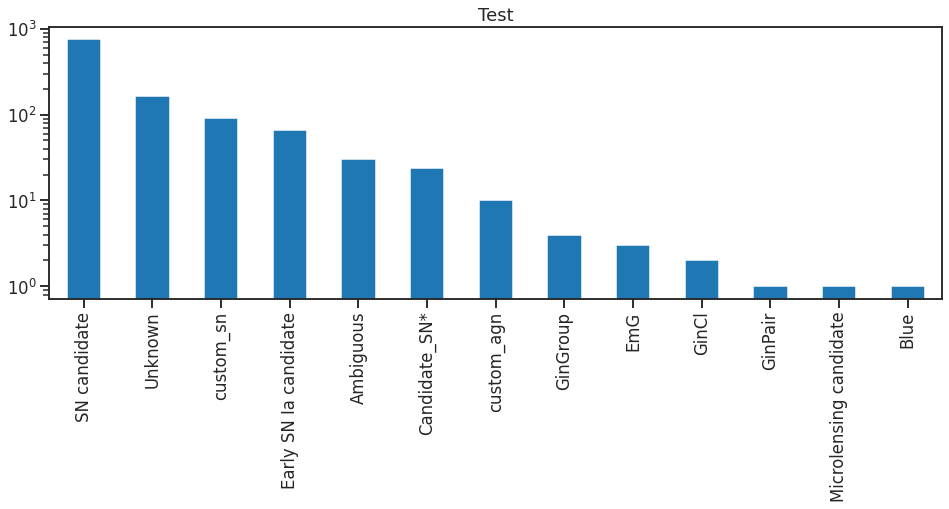

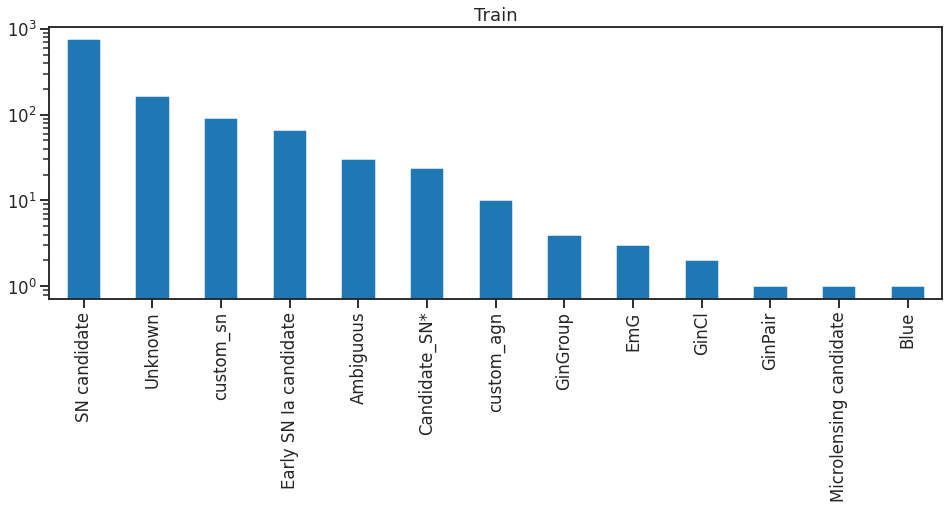

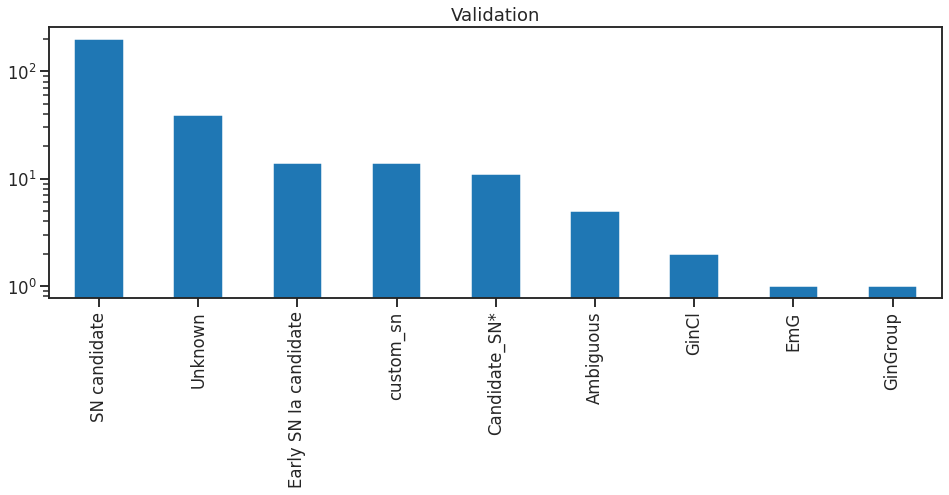

In [7]:
test_finkclasses_flatten = test_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    test_finkclasses_flatten[test_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('Test')
plt.show()

train_finkclasses_flatten = train_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    train_finkclasses_flatten[train_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('Train')
plt.show()

val_finkclasses_flatten = val_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    val_finkclasses_flatten[val_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('Validation')
plt.show()

Each row in `total_objIds` and `total_common_finkclasses` correspond to the same objectId.

### TODO: Just as I changed main processing.py to handle SN finkclasses (and use tns classes)...do required changes here also.

In [8]:
# from sklearn import preprocessing
# le = preprocessing.LabelEncoder()
# objIds_encoded = le.fit_transform(total_objIds)  # use le.inverse_transform to get the string from the encoded value.

/home/oem/.local/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/oem/.local/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:805: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


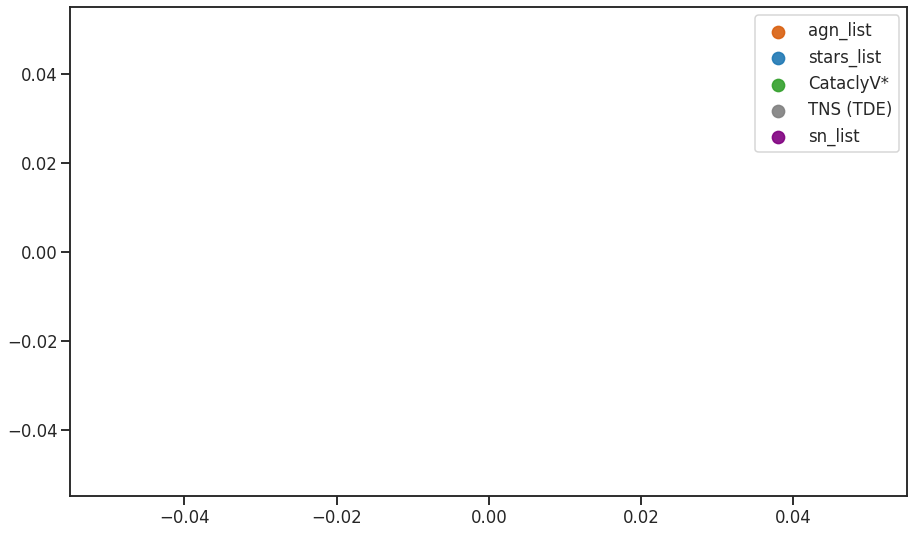

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import umap
from sklearn.manifold import TSNE

test_outputs_condensed_condensed = test_outputs_condensed.mean(1).mean(2)
# test_outputs_condensed_condensed = test_outputs_condensed_condensed[:, :6]  # Because most light curves have ~<10 datapoints. See the histogram below.
# test_outputs_condensed_condensed = test_outputs_condensed[:, 0, :, :].mean(2)

agn_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in agn_list]) > 0 else 0, 1, test_finkclasses)
stars_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in stars_list]) > 0 else 0, 1, test_finkclasses)
# simbad_galaxies_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in simbad_galaxies_list]) > 0 else 0, 1, test_finkclasses)
cataclyv_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['CataclyV*']]) > 0 else 0, 1, test_finkclasses)
tns_tde_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)
sn_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in sn_list]) > 0 else 0, 1, test_finkclasses)

colors = ['#d95f0e', '#1f78b4', '#df65b0', '#33a02c', 'gray', 'purple']

pca = False
umap_use = False
tsne = True

test_outputs_condensed_condensed_scaled = StandardScaler().fit_transform(test_outputs_condensed_condensed)

if pca:
    test_outputs_condensed_condensed_transformed = PCA(n_components=2).fit_transform(test_outputs_condensed_condensed_scaled)
elif umap_use:
    test_outputs_condensed_condensed_transformed = umap.UMAP(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)
elif tsne:
    test_outputs_condensed_condensed_transformed = TSNE(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)

fig, ax = plt.subplots(1, 1, figsize=(15, 9))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][agn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_indicator==1],
    c=colors[0], label='agn_list', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][stars_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator==1],
    c=colors[1], label='stars_list', s=150, alpha=0.9
)

# ax.scatter(
#     test_outputs_condensed_condensed_transformed[:, 0][simbad_galaxies_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][simbad_galaxies_indicator==1],
#     c=colors[2], label='simbad_galaxies_list', s=150, alpha=0.9
# )

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator==1],
    c=colors[3], label='CataclyV*', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator==1],
    c=colors[4], label='TNS (TDE)', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][sn_indicator==1],
    c=colors[5], label='sn_list', s=150, alpha=0.9
)
ax.legend()

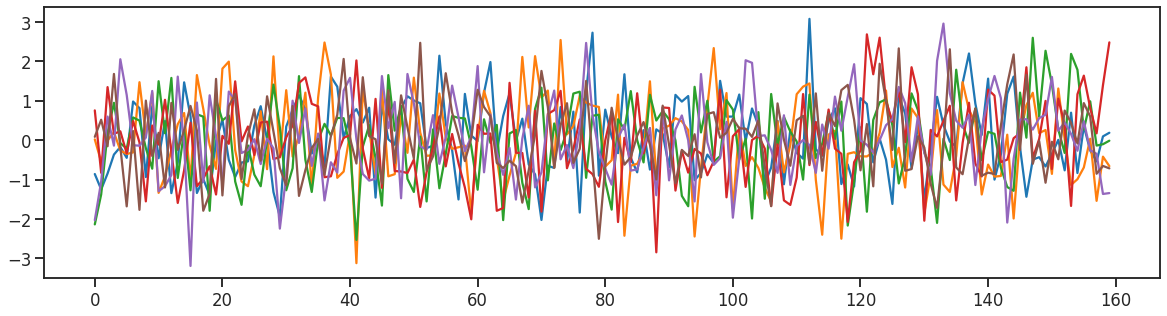

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for i in range(len(test_outputs_condensed_condensed)):
    ax.plot(test_outputs_condensed_condensed[i, :])
    if i == 5:
        break

In [11]:
# for oie in objIds_encoded:
#     objId = le.inverse_transform([oie])[0]
#     finkclass = objIds_finkclass_all[objIds_finkclass_all['objectId'] == objId]['finkclass'].tolist()
#     print(oie, objId, finkclass)

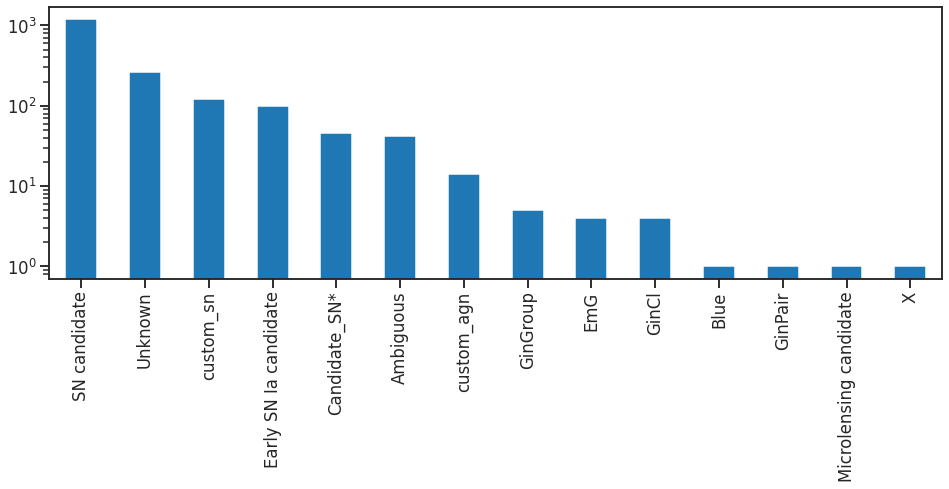

In [12]:
total_common_finkclasses_flatten = total_common_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    total_common_finkclasses_flatten[total_common_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

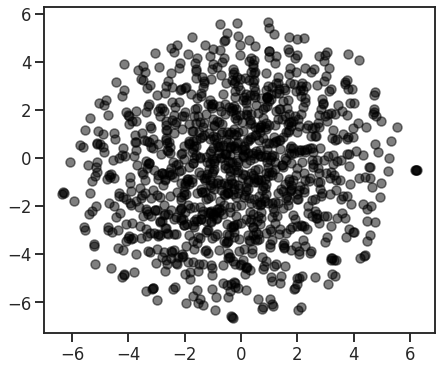

In [13]:
# indicator = []
# for i, oi in enumerate(total_objIds):
#     if oi not in test_objIds:
#         continue
#     # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
#     fclasses = total_common_finkclasses[i, :]
#     if 'CataclyV*' in fclasses:
#         indicator.append(1)
#     else:
#         indicator.append(0)

# indicator = np.array(indicator)

indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['CataclyV*']]) > 0 else 0, 1, test_finkclasses)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

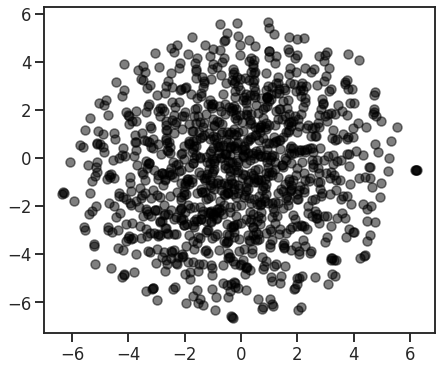

In [14]:
# indicator = []
# for i, oi in enumerate(total_objIds):
#     if oi not in test_objIds:
#         continue
#     # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
#     fclasses = total_common_finkclasses[i, :]
#     if 'custom_stars' in fclasses:
#         indicator.append(1)
#     else:
#         indicator.append(0)

# indicator = np.array(indicator)

indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in stars_list]) > 0 else 0, 1, test_finkclasses)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

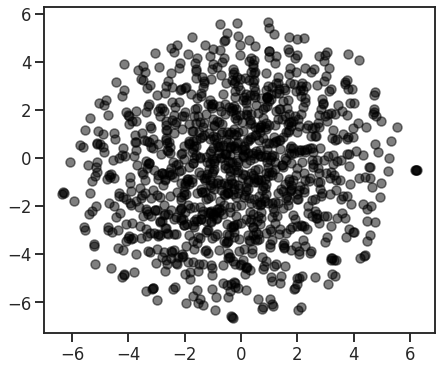

In [15]:
# indicator = []
# for i, oi in enumerate(total_objIds):
#     if oi not in test_objIds:
#         continue
#     # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
#     fclasses = total_common_finkclasses[i, :]
#     if 'custom_agn' in fclasses:
#         indicator.append(1)
#     else:
#         indicator.append(0)

# indicator = np.array(indicator)

indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in agn_list]) > 0 else 0, 1, test_finkclasses)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

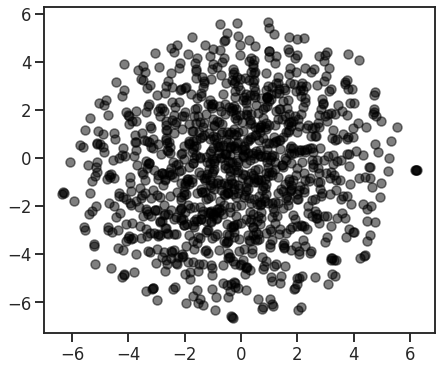

In [16]:
# indicator = []
# for i, oi in enumerate(total_objIds):
#     if oi not in test_objIds:
#         continue
#     # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
#     fclasses = total_common_finkclasses[i, :]
#     if 'custom_sn' in fclasses:
#         indicator.append(1)
#     else:
#         indicator.append(0)

# indicator = np.array(indicator)

indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in sn_list]) > 0 else 0, 1, test_finkclasses)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

## Checking for the cases added manually

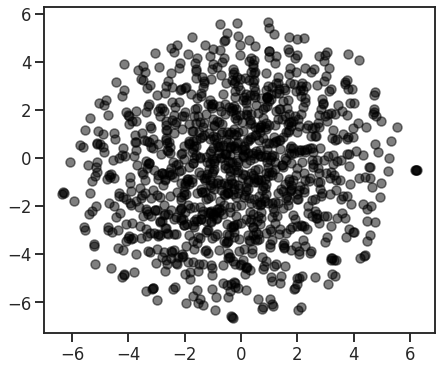

In [17]:
tns_tde_objId_list = ['ZTF24aaahxwr', 'ZTF24aaecooj', 'ZTF20aahmtso', 'ZTF22aafujzv', 'ZTF22aadesap', 'ZTF18aabdajx', 'ZTF21aanxhjv', 'ZTF22abegjtx']

# indicator = []
# for i, oi in enumerate(total_objIds):
#     if oi not in test_objIds:
#         continue
#     # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
#     fclasses = total_common_finkclasses[i, :]
#     if oi in tns_tde_objId_list:
#         indicator.append(1)
#     else:
#         indicator.append(0)

# indicator = np.array(indicator)

indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

## Looking at the light curves

In [50]:
df_alerts = pd.read_parquet('alerts_processed_ftransfer_ztf_2024_04_26_572037_copy.parquet')
df_alerts.shape

(56327, 20)

In [51]:
df_alerts.head(2)

,objectId,candid,magpsf,sigmapsf,fid,jd,ra,dec,tnsclass,cdsxmatch,roid,mulens,snn_snia_vs_nonia,snn_sn_vs_all,rf_snia_vs_nonia,rf_kn_vs_nonkn,tracklet,lc_features_g,lc_features_r,finkclass
0,ZTF19aanbpus,1438498770915015007,17.001005,0.081461,2,2.459193e+06,150.966244,59.436076,(TNS) SN IIb,AGN,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.6658506393432617, 'anderson_da...","{'amplitude': 0.43320274353027344, 'anderson_d...",custom_agn
1,ZTF18abreeqx,1334470924015010000,17.752148,0.064367,1,2.459089e+06,29.519780,-0.872732,(TNS) SN II,AGN,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.2424001693725586, 'anderson_da...","{'amplitude': 0.10105037689208984, 'anderson_d...",custom_agn


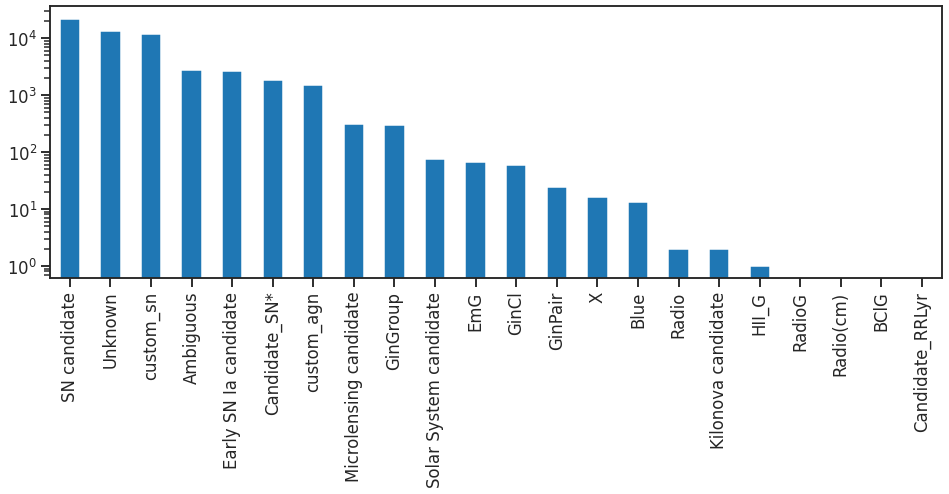

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
df_alerts['finkclass'].value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

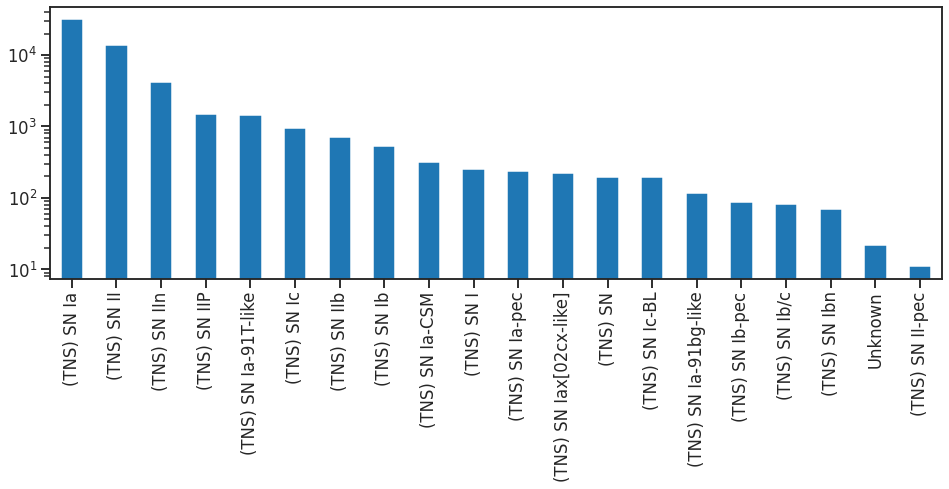

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
df_alerts['tnsclass'].value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

In [21]:
test_cv_objIds = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if 'CataclyV*' in fclasses:
        test_cv_objIds.append(oi)

for test_cv_objId in test_cv_objIds:
    plot_lc(df_alerts, test_cv_objId)

## Old analysis

Selecting points in the latent space manually and plotting their light curves to search for similarity

### Example 1

In [22]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] > 3) & (outputs_condensed_condensed_transformed[:, 1] > 1)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

NameError: name 'outputs_condensed_condensed_transformed' is not defined

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

In [ ]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

In [ ]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

In [ ]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] < -2.5) & (outputs_condensed_condensed_transformed[:, 1] < -1.9)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

In [ ]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

In [ ]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

Example 3

In [ ]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] < -2) & (outputs_condensed_condensed_transformed[:, 0] > -3) &
    (outputs_condensed_condensed_transformed[:, 1] > -1.5) & (outputs_condensed_condensed_transformed[:, 1] < -1)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

In [ ]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

In [ ]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

## No. of datapoints in light curves across the entire dataset

TODO: Make a detailed analysis of seq_len vs their finkclass (most-common-across-alerts). I previously saw only SN and SN-candidate to have seq_len > 30.

TODO: Is seq_len a good indicator of light curve duration? seq_len is total no. of datapoints including all bands. Perhaps we just need `max_length(pdf[filter1], pdf[filter2])`

In [23]:
def get_lc(
        df_alerts, name, fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        objectId_column='objectId', sigmapsf_column='sigmapsf', finkclass_column='finkclass',
        #extract_subset=False, start_index=None, end_index=None
        make_first_time_zero=True, convert_to_tensor=False, normalize_times=False,
        local_time_normalization=False, max_time=None, min_time=None
    ):
    """Get the light curve given an alerts dataframe (df_alerts) and the objectId (name).
    
    Returns a tuple (object_Id, tt, vals, mask, labels)
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}, so cannot make a light curve!')

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    observation_data, observation_mask = [], []
    # for filt in np.unique(pdf['fid']):
    # Don't loop over pdf['fid'] since in pdf, we might not get all filters. For creating the dataset, we need fixed-sized arrays, so we should select all filters instead of filters seen in this pdf.
    for filt in np.unique(df_alerts[fid_column]):
        #if extract_subset:
        #    maskFilt = pdf[fid_column] == filt
        #    observation_data.append(
        #        (pdf[magpsf_column] * maskFilt).iloc[start_index:end_index]
        #    )
        #    observation_mask.append(
        #        maskFilt.astype(int)
        #    )
        #else:
        maskFilt = pdf[fid_column] == filt
        observation_data.append(
            pdf[magpsf_column] * maskFilt  # because when observation for this filter is not present, we want to replace the observed value with zero, as done in the mTAN code.
        )
        observation_mask.append(
            maskFilt.astype(int)
        )

    observation_data = np.array(observation_data).T  # after transpose: seqlen x num_channels
    observation_mask = np.array(observation_mask).T  # after transpose: seqlen x num_channels

    times = np.expand_dims(pdf[jd_column], 1)  # Add dimension at the 1st index to prepare for concatenation.
    #data = np.concatenate((observation_data, observation_mask, times), axis=1)

    if make_first_time_zero:
        # As per the Physionet dataset (at least) from the mTAN paper, the times always start at zero. Their time units are also in hours. So this replicates that.
        # Make the first time to zero. The below two lines are only for machine learning purposes since the time must always start at zero for all light curves.
        times = times - times[0]
        #times = times * 24  # to convert times into hours.

    if normalize_times:
        # NOTE: If you use get_lc for different length light curves, note the possible caveat that a normalized time value of 1 means the same for two very different length light curves. It's possible that despite this, the relative difference in the times already encodes the information about different duration/length light curves. Not sure definitively.
        times = normalize_time_values(times, local_time_normalization=local_time_normalization, max_time=max_time, min_time=min_time)

    if finkclass_column is not None:  # finkclass_column will be None when getting the light curve from the API service instead of polling the alerts.
        common_finkclasses = df_alerts[df_alerts[objectId_column] == name][finkclass_column].mode().tolist()
    else:
        common_finkclasses = [None]

    if convert_to_tensor:
        times = torch.from_numpy(times)
        observation_data = torch.from_numpy(observation_data)
        observation_mask = torch.from_numpy(observation_mask)

    data = (name, times, observation_data, observation_mask, common_finkclasses)

    return data

def normalize_time_values(times, local_time_normalization=False, max_time=None, min_time=None):
    """`times` must start with zero and be in units of hours. This function assumes that.
    times are multipled by 48 after normalization which means the normalized time valus lie in [0, 48] hours.
    """
    if local_time_normalization:
        normalized_times = (times - np.min(times)) / (np.max(times) - np.min(times))
    else:  # Means global normalization must be used. In this case, max_time argument will be used.
        if max_time is None or min_time is None:
            raise ValueError("max_time and min_time both must be provided if using global time normalization.")
        assert max_time > np.min(times)  # Otherwise time will become negative.
        normalized_times = (times - min_time) / (max_time - min_time)
    normalized_times *= 48  # Doing this is not needed since anyways variable_time_collate_fn will normalize to the [0, 1] range.
    return normalized_times

32.003977272727276 19.0


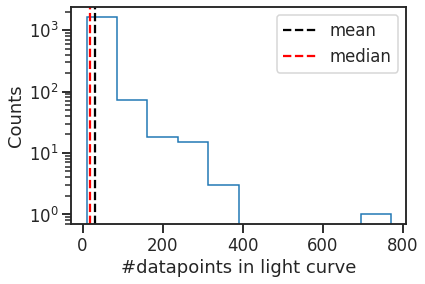

In [24]:
import numpy as np
import pandas as pd

num_data_points_all = []

for objId in df_alerts['objectId'].unique():
    data = get_lc(df_alerts, objId, make_first_time_zero=False, convert_to_tensor=False)
    # data = (name, times, observation_data, observation_mask, common_finkclasses)
    num_data_points_all.append(len(data[1]))

import matplotlib.pyplot as plt
plt.hist(num_data_points_all, histtype='step')
plt.yscale('log')
plt.xlabel('#datapoints in light curve')
plt.ylabel('Counts')
plt.axvline(x=np.mean(num_data_points_all), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(num_data_points_all), linestyle='--', c='red', label='median')
plt.legend()
# plt.savefig('num_datapoints_all.png', bbox_inches='tight')

print(np.mean(num_data_points_all), np.median(num_data_points_all))

112.6071166197055 49.98956014984287


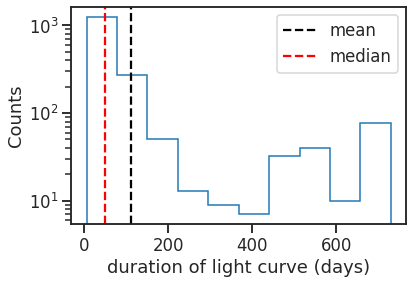

In [25]:
import numpy as np
import pandas as pd

duration_lcs = np.load('duration_lcs.npy')

import matplotlib.pyplot as plt
plt.hist(duration_lcs, histtype='step')
plt.yscale('log')
plt.xlabel('duration of light curve (days)')
plt.ylabel('Counts')
plt.axvline(x=np.mean(duration_lcs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(duration_lcs), linestyle='--', c='red', label='median')
plt.legend()

print(np.mean(duration_lcs), np.median(duration_lcs))

## `max_mag - min_mag` across light curves

This is calculated across all bands for a given light curve.

1.7010514730756934 1.5574445724487305 1.0560178756713867 0.8564906606355526


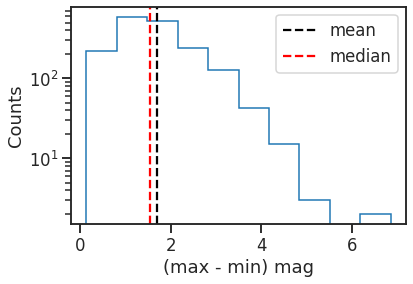

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import iqr

min_max_magdiffs = np.load('min_max_magdiffs.npy')

import matplotlib.pyplot as plt
plt.hist(min_max_magdiffs, histtype='step')
plt.yscale('log')
plt.xlabel('(max - min) mag')
plt.ylabel('Counts')
plt.axvline(x=np.mean(min_max_magdiffs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(min_max_magdiffs), linestyle='--', c='red', label='median')
plt.legend()

print(np.mean(min_max_magdiffs), np.median(min_max_magdiffs), iqr(min_max_magdiffs), np.std(min_max_magdiffs))

In [40]:
inds = np.where(min_max_magdiffs > 4)
total_objIds[inds], total_common_finkclasses[inds]

(array(['ZTF21aaqwjlz', 'ZTF20acoyfpk', 'ZTF21aagqcnl', 'ZTF21abpxquj',
        'ZTF21aarqkes', 'ZTF21aafdxca', 'ZTF20acxzqyp', 'ZTF21aaqftuq',
        'ZTF21aaqgmjt', 'ZTF21aavqphe', 'ZTF21aaqftpz', 'ZTF20adadrhw',
        'ZTF21aagsihi', 'ZTF20abotkfn', 'ZTF21aaabvjk', 'ZTF21acpfndw',
        'ZTF20acpjqxp', 'ZTF21aaampui', 'ZTF21aaihala', 'ZTF20acpjapi',
        'ZTF21abuibjs', 'ZTF20acpiywu', 'ZTF20abeohfn', 'ZTF20aaynrrh',
        'ZTF21acdsnsh', 'ZTF20aavpnlv', 'ZTF20abqvsik', 'ZTF18abtgyme',
        'ZTF20achlced', 'ZTF20acggqfs', 'ZTF20abeywdn'], dtype='<U12'),
 array([['SN candidate', '0'],
        ['Ambiguous', '0'],
        ['SN candidate', '0'],
        ['SN candidate', '0'],
        ['SN candidate', '0'],
        ['Unknown', '0'],
        ['SN candidate', '0'],
        ['Unknown', '0'],
        ['SN candidate', '0'],
        ['SN candidate', '0'],
        ['Unknown', '0'],
        ['Candidate_SN*', '0'],
        ['SN candidate', '0'],
        ['Unknown', '0'],
        ['Un

## Projection (PCA/UMAP/t-SNE) colored with

### min mags of lcs

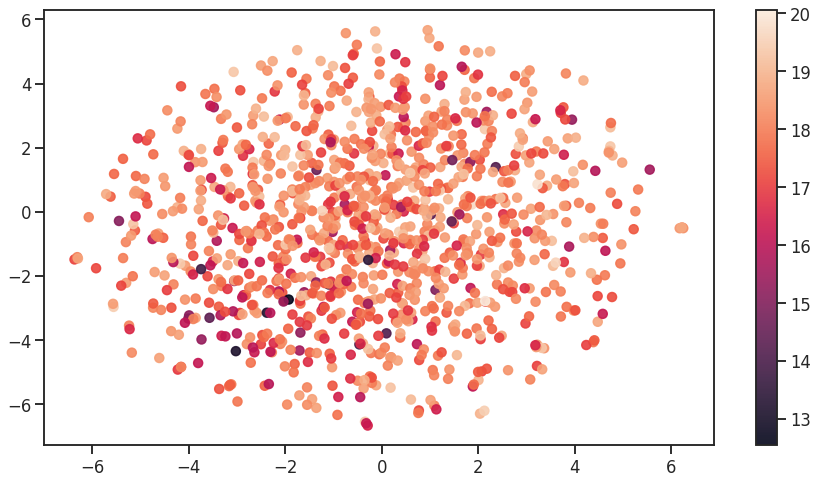

In [27]:
min_mags = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    min_mags.append(obs[obs != 0.0].min())

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=min_mags, alpha=0.9
)
plt.colorbar(sc)

### length of light curve

Text(0, 0.5, '$\\log_{10}(\\mathrm{lc\\_length})$')

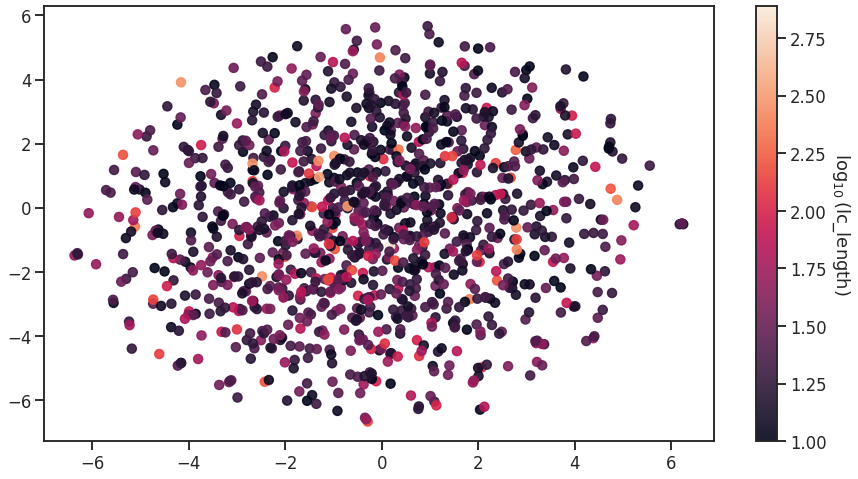

In [28]:
length_lc = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    length_lc.append(len(data[1]))

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=np.log10(length_lc), alpha=0.9
)
cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('$\log_{10}(\mathrm{lc\_length})$', rotation=270, labelpad=25)

### mean mag

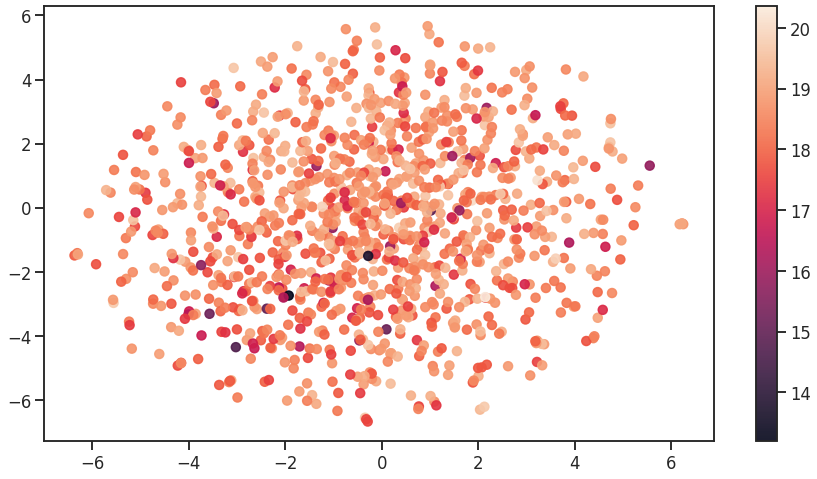

In [29]:
mean_mags = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    mean_mags.append(obs[obs != 0.0].mean())

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=mean_mags, alpha=0.9
)
plt.colorbar(sc)

### finkclass

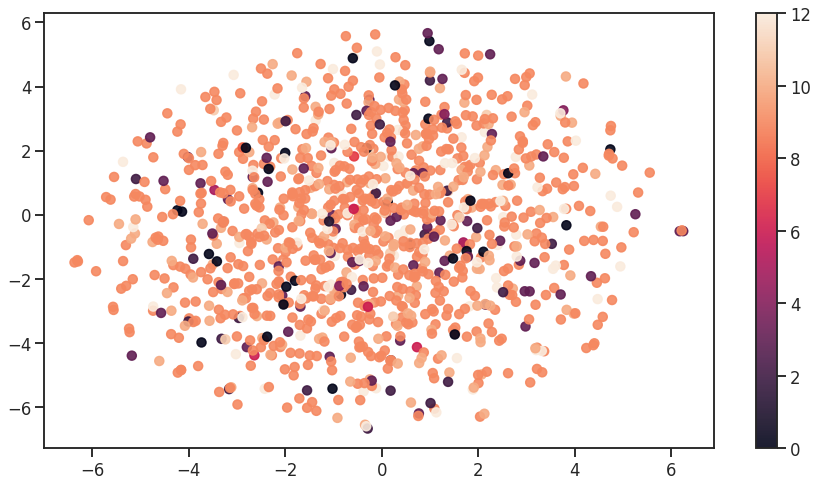

In [30]:
finkclasses = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    cl = data[-1][0]
    finkclasses.append(cl)

from sklearn import preprocessing
le = preprocessing.LabelEncoder()
finkclasses_encoded = le.fit_transform(finkclasses)  # use le.inverse_transform to get the string from the encoded value.

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=finkclasses_encoded, alpha=0.9
)
plt.colorbar(sc)

## Length of light curve vs finkclass

In [31]:
finkclasses = []
length_lc =[]
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    cl = data[-1][0]
    len_lc = len(data[1])
    finkclasses.append(cl)
    length_lc.append(len_lc)

finkclasses = np.expand_dims(np.array(finkclasses), 1)
length_lc = np.expand_dims(np.array(length_lc), 1)
df = pd.DataFrame(np.hstack((finkclasses, length_lc)))
df.columns = ['finkclass', 'len_lc']
# ax.scatter(finkclasses, length_lc)
# plt.show()

Text(0, 0.5, 'len_lc')

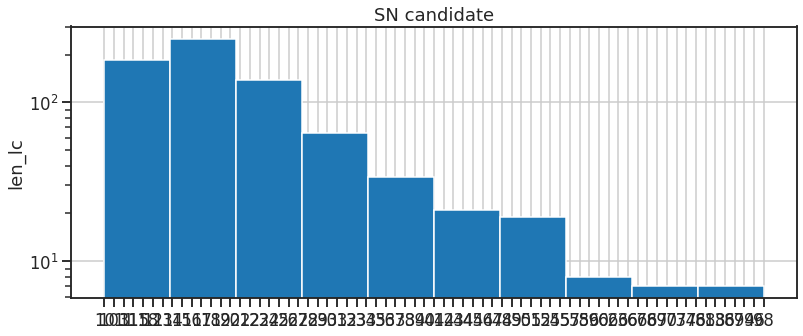

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
df[df['finkclass'] == 'SN candidate']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('SN candidate')
ax.set_ylabel('len_lc')

Text(0, 0.5, 'len_lc')

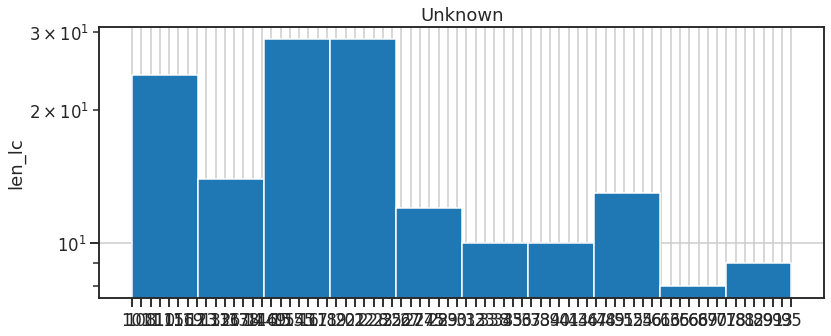

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
df[df['finkclass'] == 'Unknown']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('Unknown')
ax.set_ylabel('len_lc')

/tmp/ipykernel_28816/3215621851.py:3: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


Text(0, 0.5, 'len_lc')

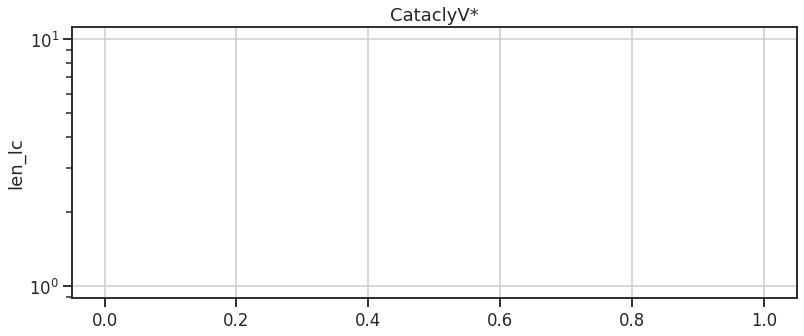

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
df[df['finkclass'] == 'CataclyV*']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('CataclyV*')
ax.set_ylabel('len_lc')

/tmp/ipykernel_28816/2260891752.py:3: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


Text(0, 0.5, 'len_lc')

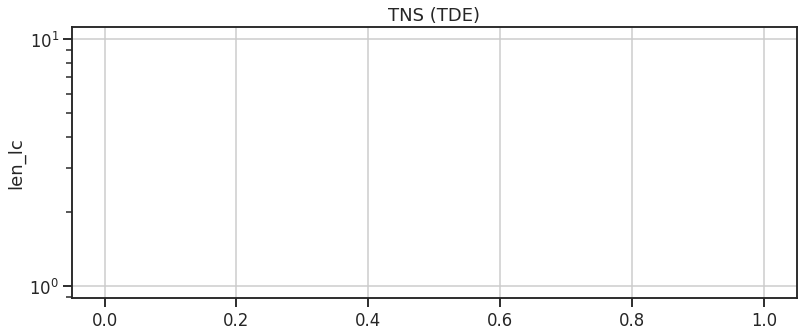

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
df[df['finkclass'] == 'TNS (TDE)']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('TNS (TDE)')
ax.set_ylabel('len_lc')

## Show random light curves

Main point of analysis is to see qualitatively how many light curves are uninteresting (flat with mostly noise).

In [36]:
print(list(df_alerts['finkclass'].unique()))

['custom_agn', 'Ambiguous', 'Blue', 'Candidate_SN*', 'Early SN Ia candidate', 'EmG', 'GinCl', 'GinGroup', 'GinPair', 'HII_G', 'Kilonova candidate', 'Microlensing candidate', 'Radio', 'SN candidate', 'custom_sn', 'Solar System candidate', 'Unknown', 'X']


In [41]:
np.random.seed(42)
random_objIds = np.random.choice(
    # df_alerts['objectId'].unique(), size=15, replace=False
    df_alerts[df_alerts['finkclass'] == 'custom_stars']['objectId'].unique(), size=4, replace=False
)

for oi in random_objIds:
    plot_lc(df_alerts, oi)

ValueError: 'a' cannot be empty unless no samples are taken

## Show the values of times

In [43]:
# for i, objId in enumerate(df_alerts['objectId'].unique()):
#     data = get_lc(df_alerts, objId, make_first_time_zero=True, convert_to_tensor=False, normalize_times=False)
#     # data = (name, times, observation_data, observation_mask, common_finkclasses)
#     # print(normalize_times(data[1]))
#     print(data[1])
#     if i == 10:
#         break

## Visualize decoded light curves

We don't want to do interpolation, so instead of aiming for a perfect interpolation that matches with the observed points closely, the decoded light curves must only be able to capture relevent features of the light curves (e.g., position and value of the peak of the lc, fade/rise times, etc)

In [44]:
decoded_lcs = np.load('evaluate_decoded_lcs.npz')

In [45]:
decoded_lcs.f.arr_2.shape

(3, 771, 2)

In [66]:
def plot_decoded_lc(decoded_lcs, key, num_filters=2):
    """
    This function assumes batch size=1 is used while storing the decoded_lcs.
    """
    pred_x, observed_data, observed_mask = decoded_lcs[key]

    print(pred_x.shape, observed_data.shape, observed_mask.shape)

    c1 = ['#2b8cbe', '#a6bddb']  # dark and then light blue
    c2 = ['#f03b20', '#feb24c']  # dark and then light orange

    colors = [c1, c2]

    fig, ax = plt.subplots(2, 1, figsize=(15, 10))
    for i in range(num_filters):
        # Set unobserved values to NaN so that they don't show up in the plot.
        obs_to_show = observed_data[:, i]
        obs_to_show[observed_mask[:, i] == 0.0] = np.nan
        ax[i].plot(range(len(obs_to_show)), obs_to_show, ls = '', marker='o', c=colors[i][1], label=f'observed_{i}')  # TODO: replace range(len(observed_data[:, 0])), with actual value of time_steps (see evaluate_unsupervised.py)
        ax[i].plot(range(len(pred_x[:, i])), pred_x[:, i], c=colors[i][0], label=f'pred_{i}')

        if i == 0:
            ax[i].set_title(key)

        ax[i].invert_yaxis()

    for a in ax:
        a.legend()

    plt.show()

# max_points_lc = -np.Inf
max_points_lc_counters = []
for counter, key in enumerate(decoded_lcs.keys()):
    if decoded_lcs[key][-1].sum() > 200:  # TODO: 200 is used based on the histogram of the #datapoints. Can change if needed.
        # max_points_lc = decoded_lcs[key][-1].sum()
        # max_points_lc_counter = counter
        max_points_lc_counters.append(counter)
    # currObjId = test_objIds[counter]
    # currObjId_index = np.where(total_objIds == currObjId)
    # currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    # currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    # plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    # plot_decoded_lc(decoded_lcs, key)
    # if counter == 10:
    #     break

In [67]:
max_points_lc_counters

[95, 180, 231, 310, 322, 450, 506, 544, 565, 592, 739, 810, 862, 888, 981, 999]

First showing the lc with the max no. of observed points. Then, some random examples.

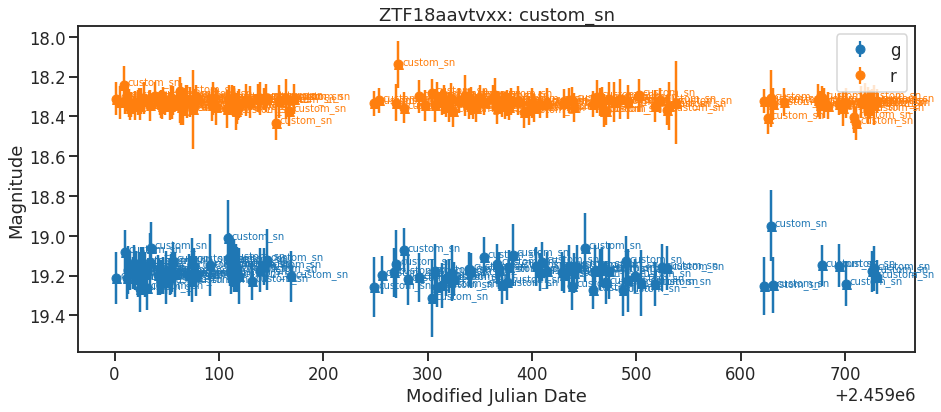

(771, 2) (771, 2) (771, 2)


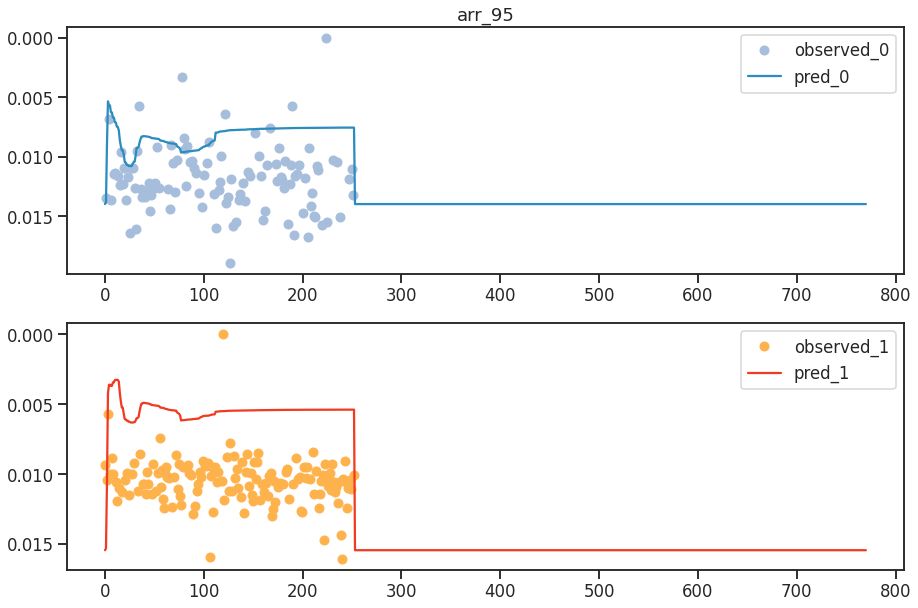

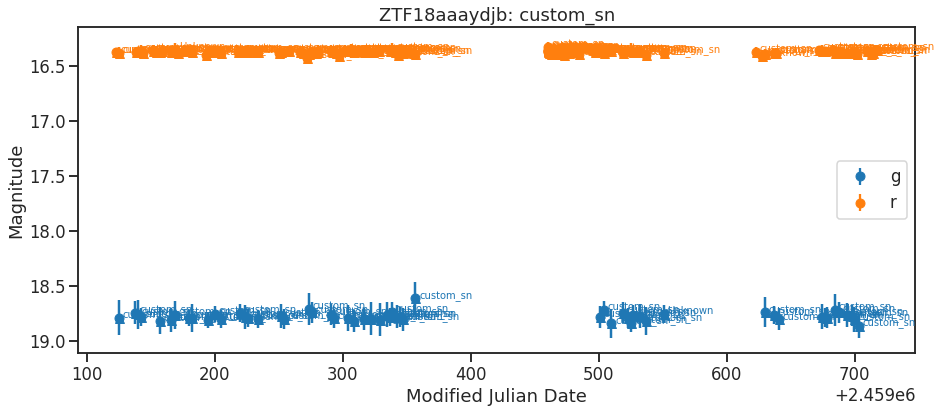

(771, 2) (771, 2) (771, 2)


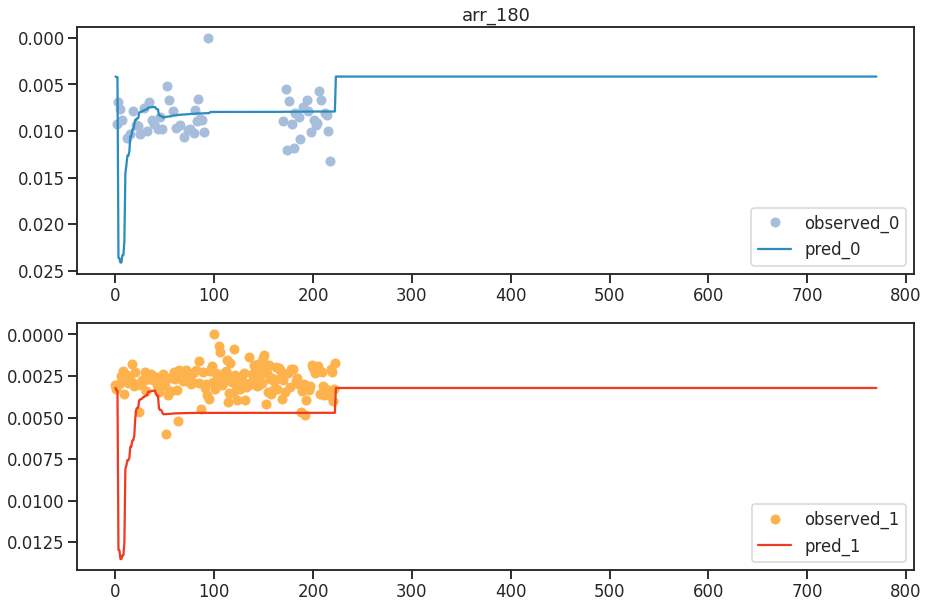

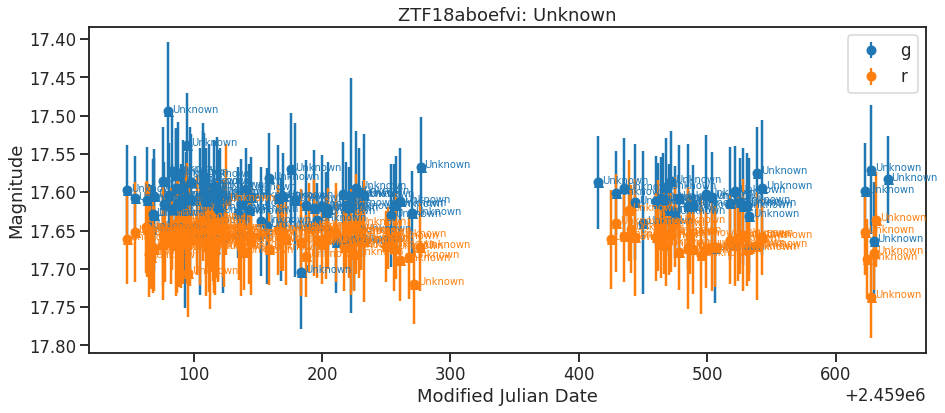

(771, 2) (771, 2) (771, 2)


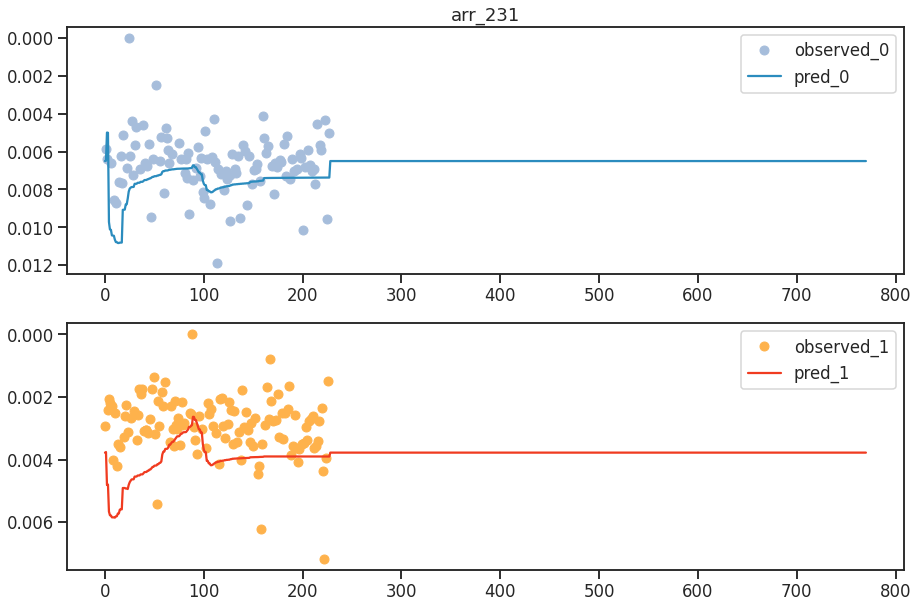

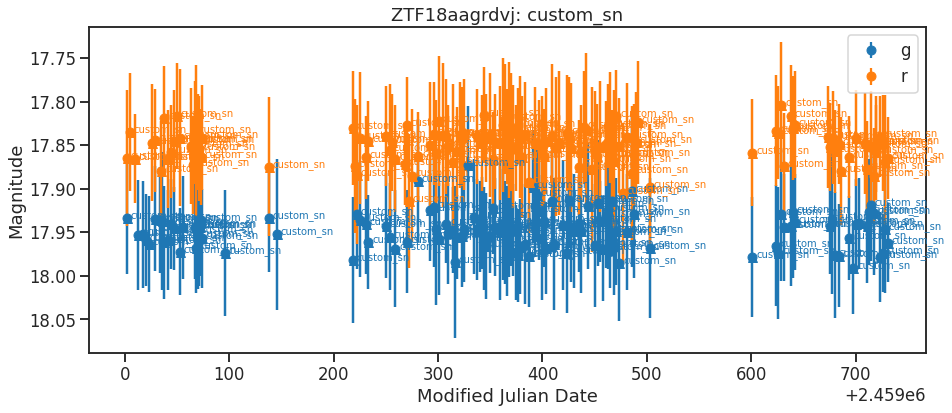

(771, 2) (771, 2) (771, 2)


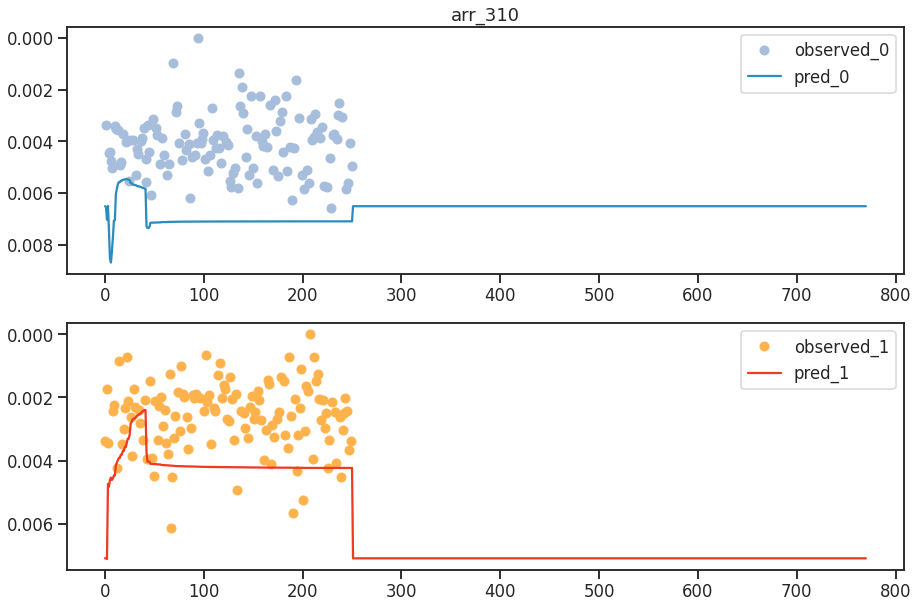

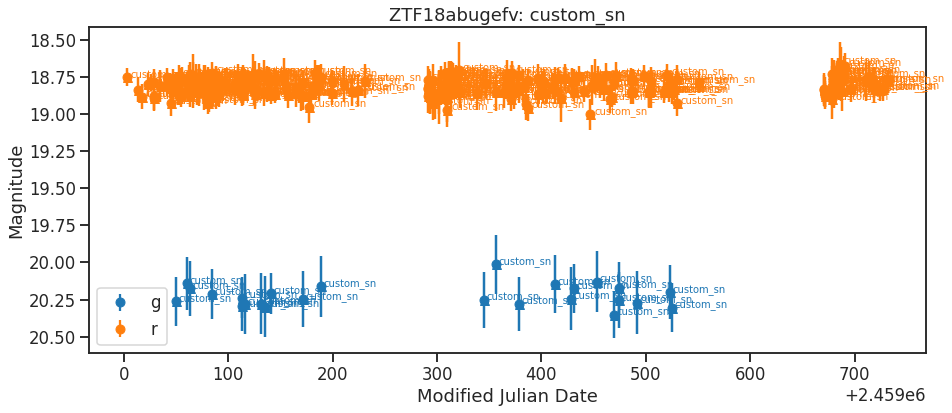

(771, 2) (771, 2) (771, 2)


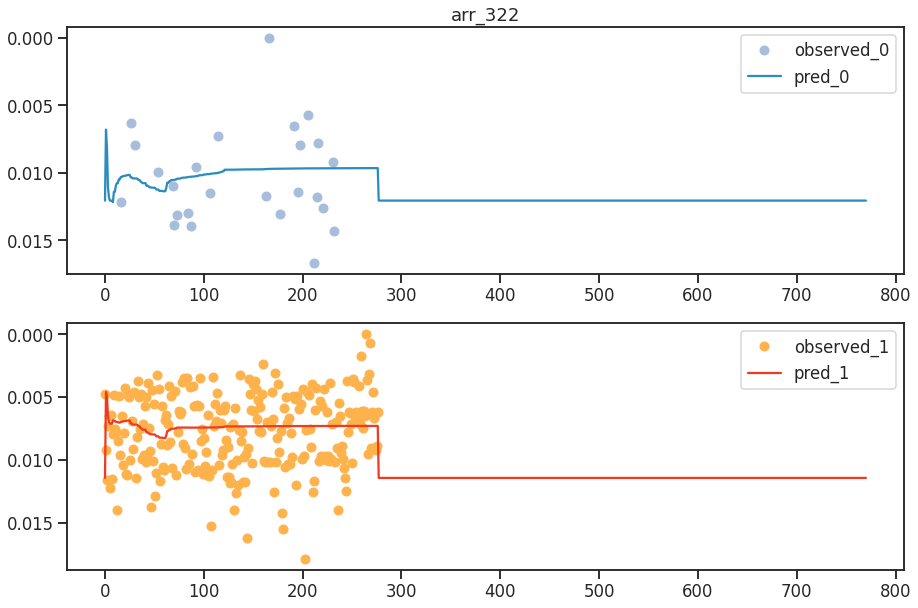

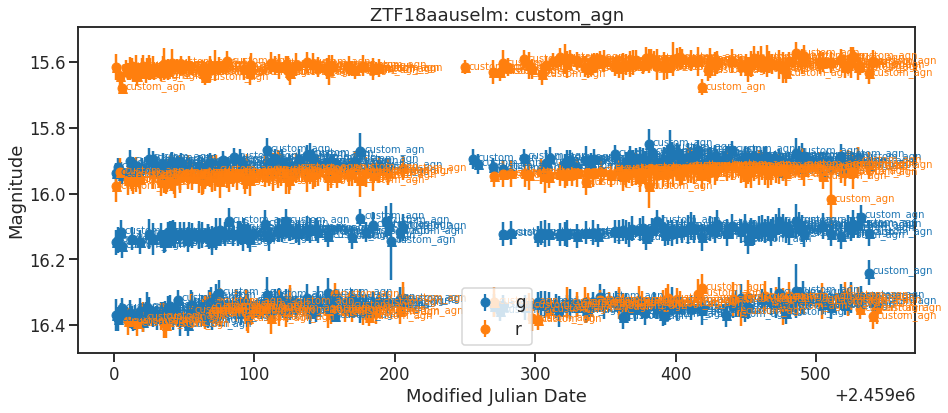

(771, 2) (771, 2) (771, 2)


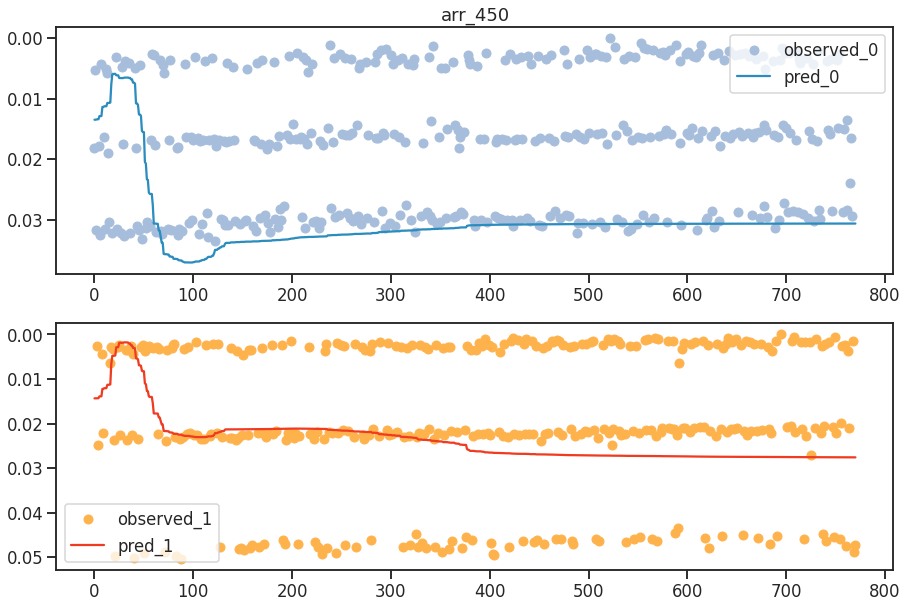

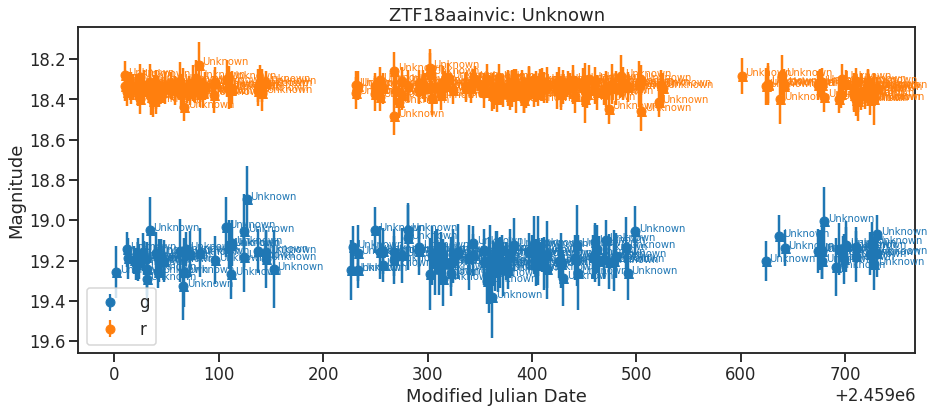

(771, 2) (771, 2) (771, 2)


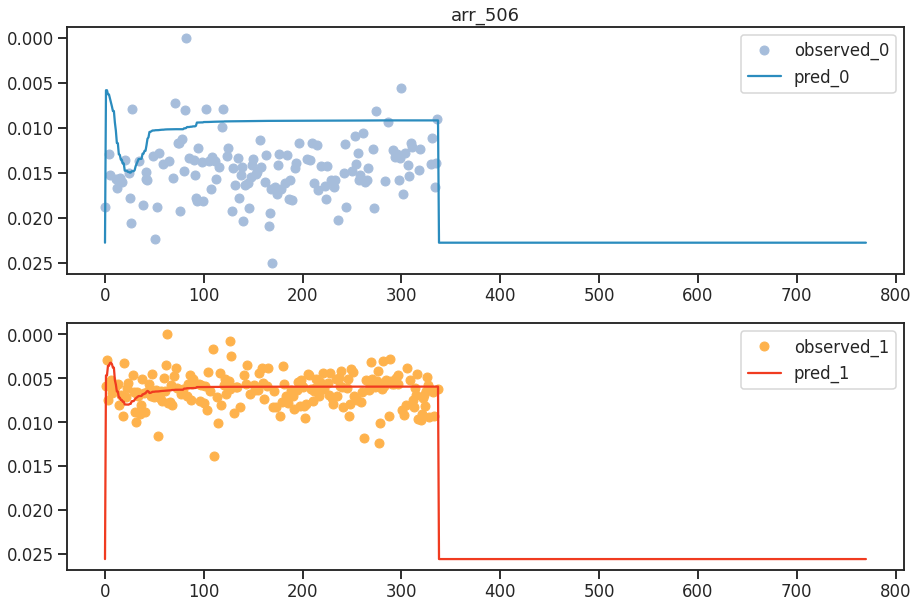

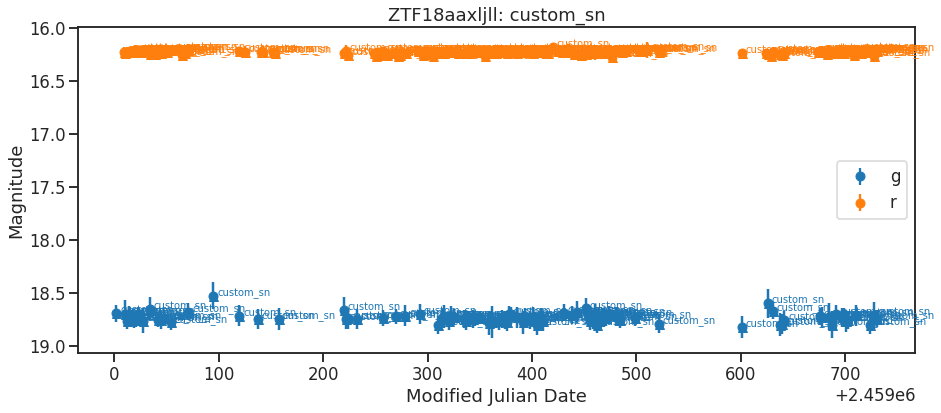

(771, 2) (771, 2) (771, 2)


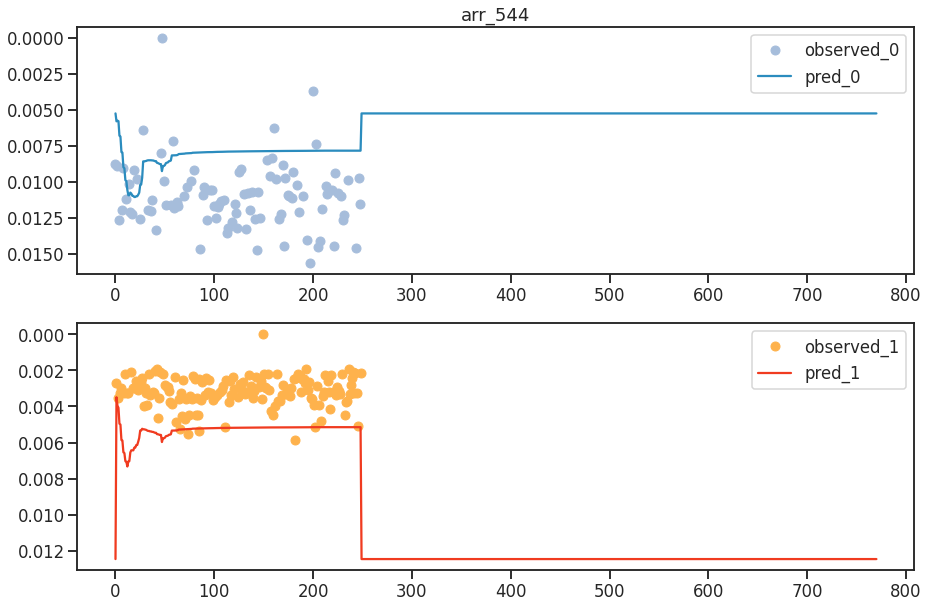

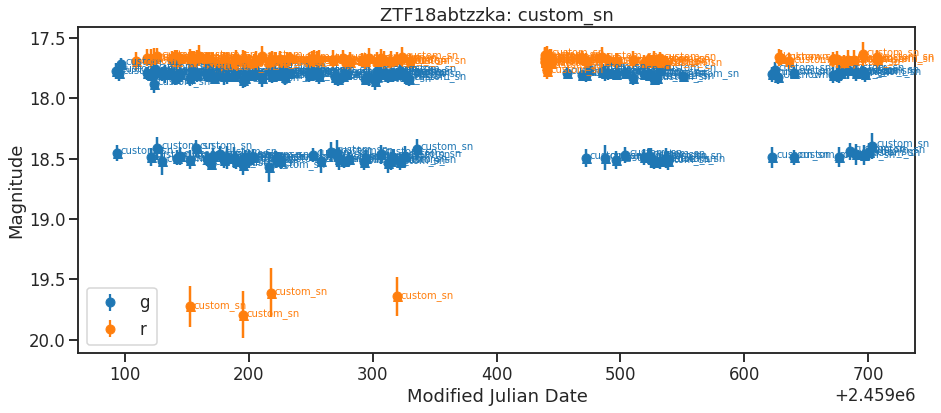

(771, 2) (771, 2) (771, 2)


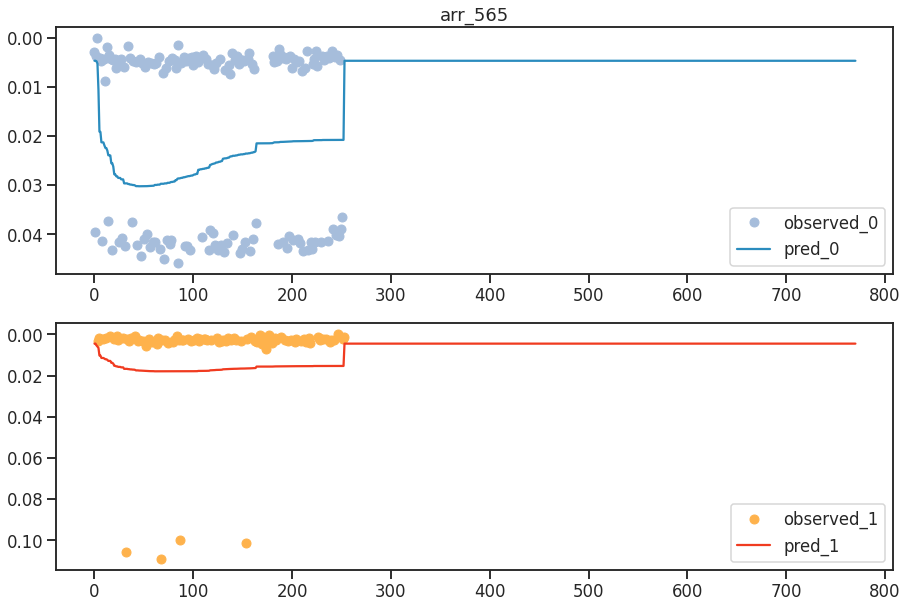

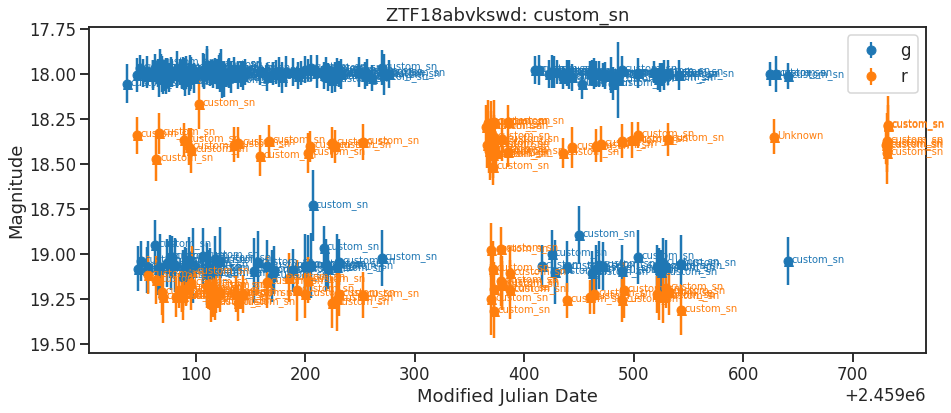

(771, 2) (771, 2) (771, 2)


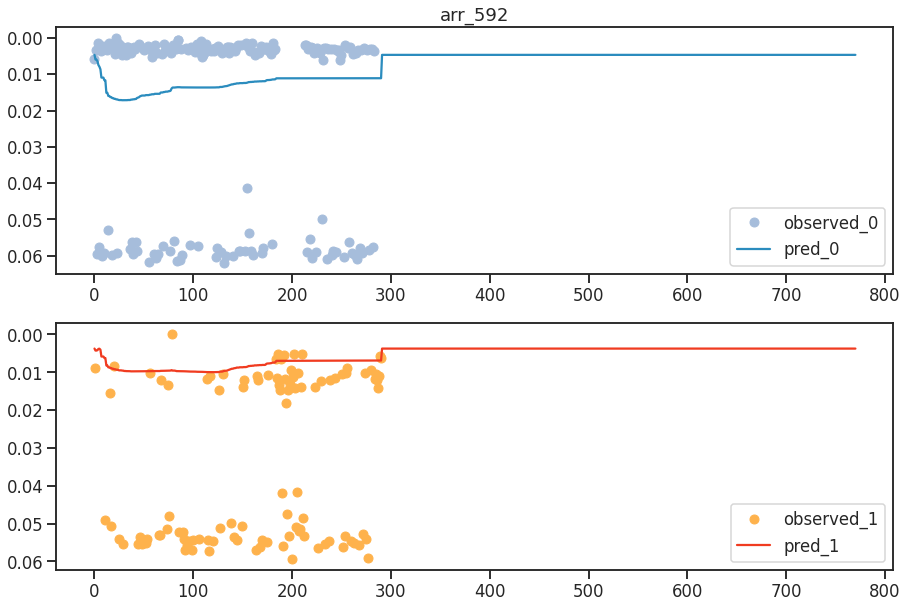

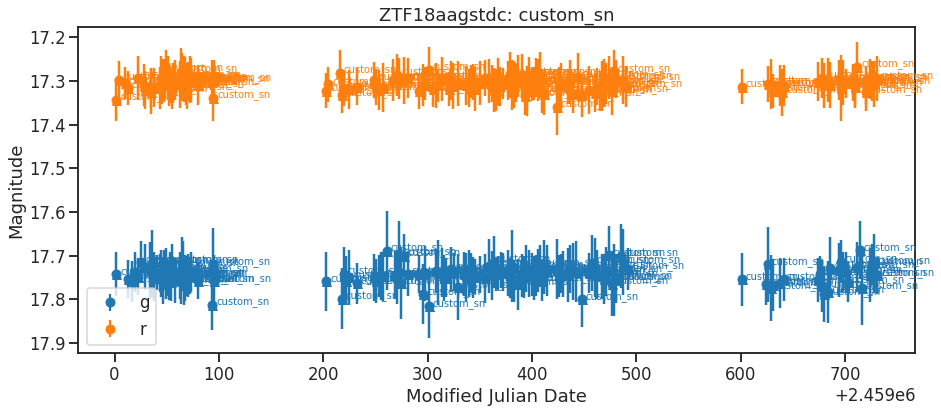

(771, 2) (771, 2) (771, 2)


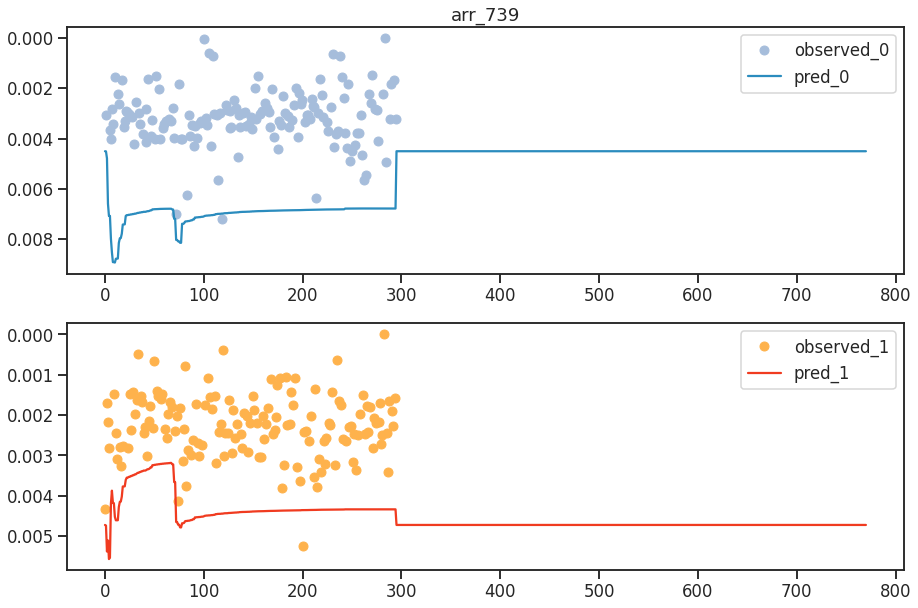

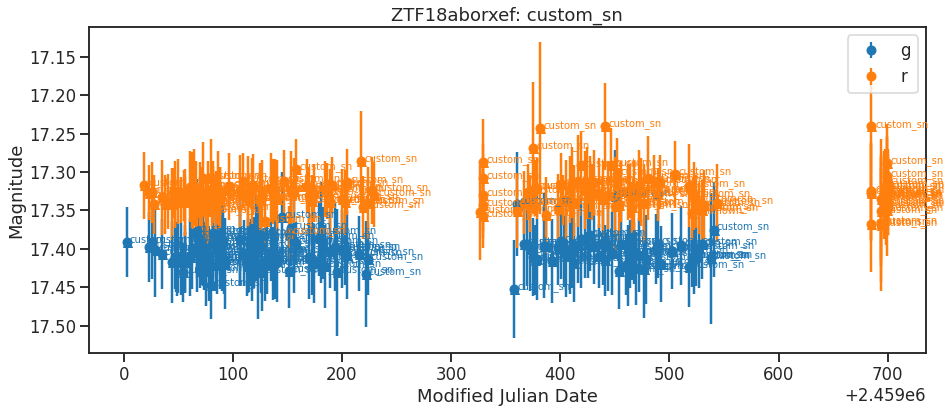

(771, 2) (771, 2) (771, 2)


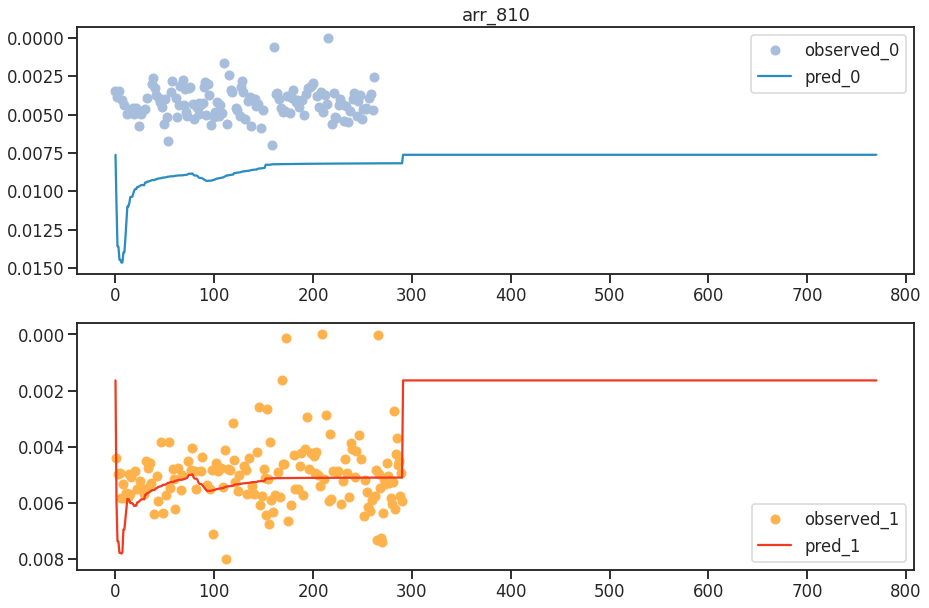

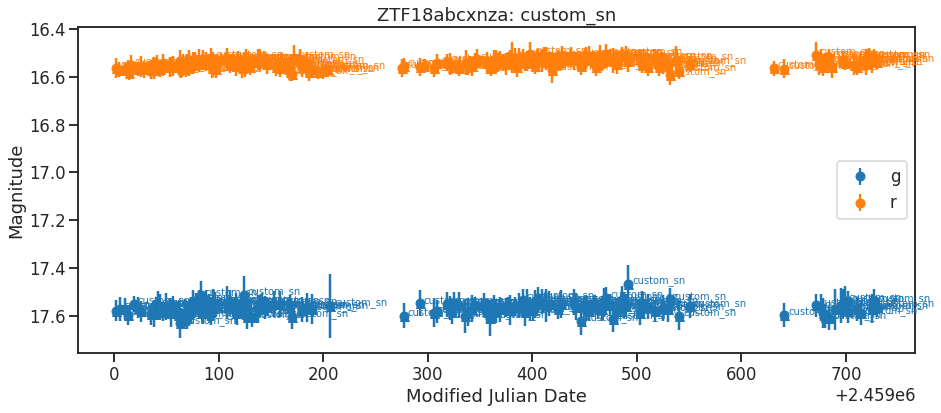

(771, 2) (771, 2) (771, 2)


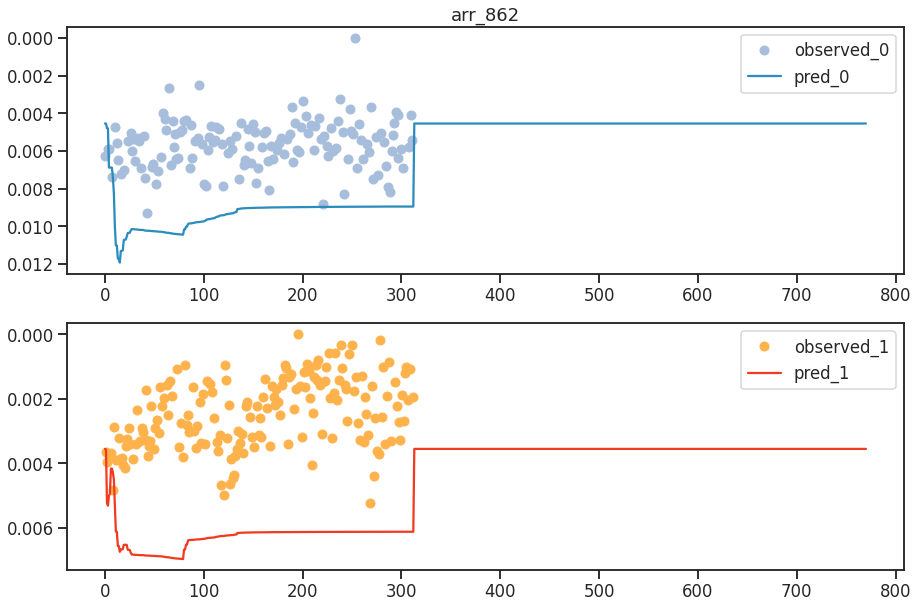

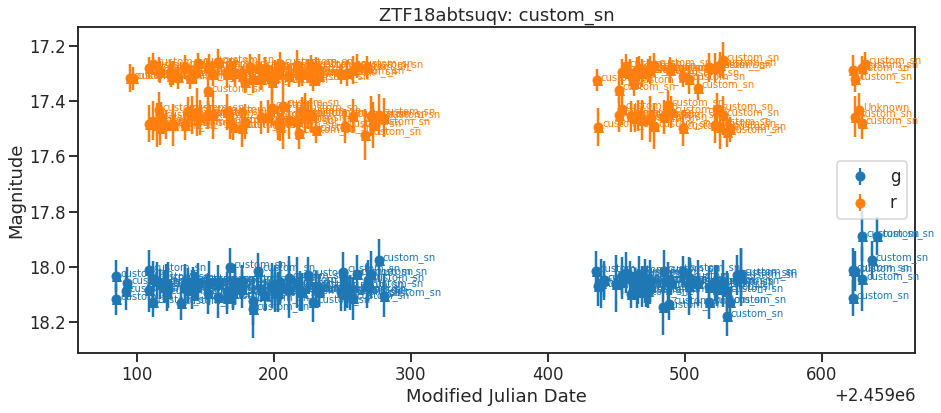

(771, 2) (771, 2) (771, 2)


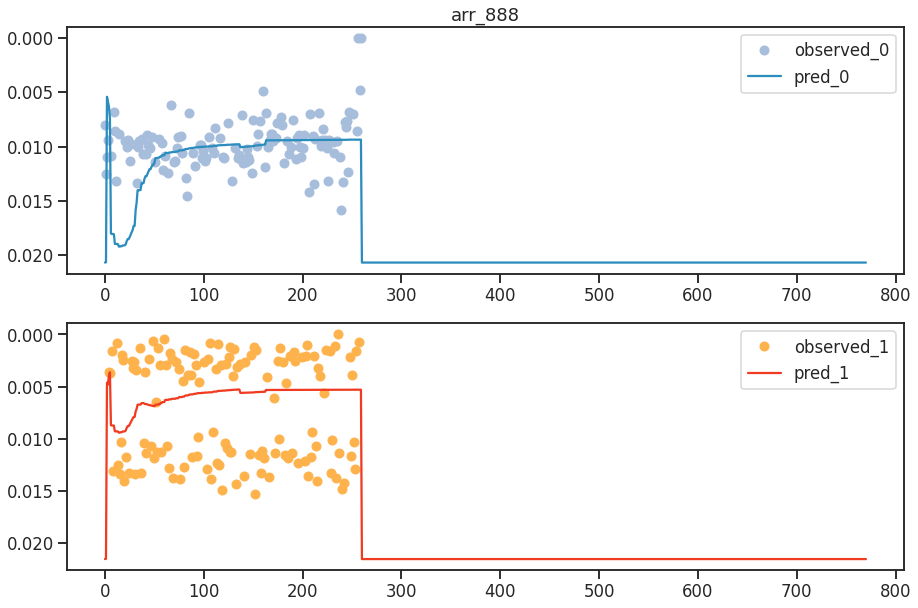

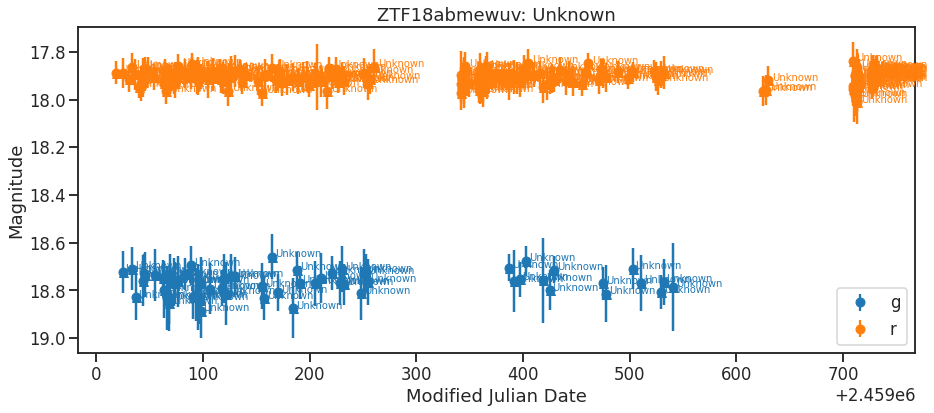

(771, 2) (771, 2) (771, 2)


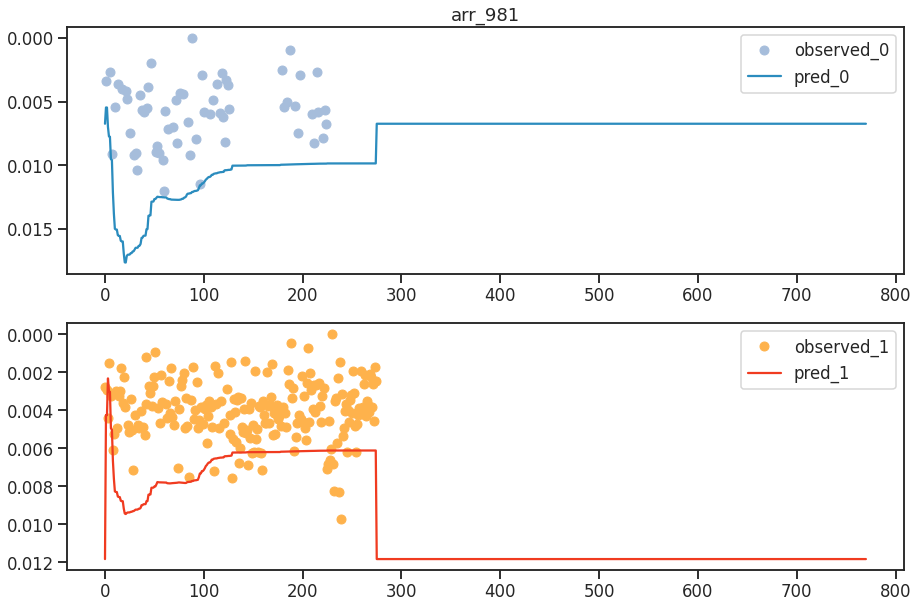

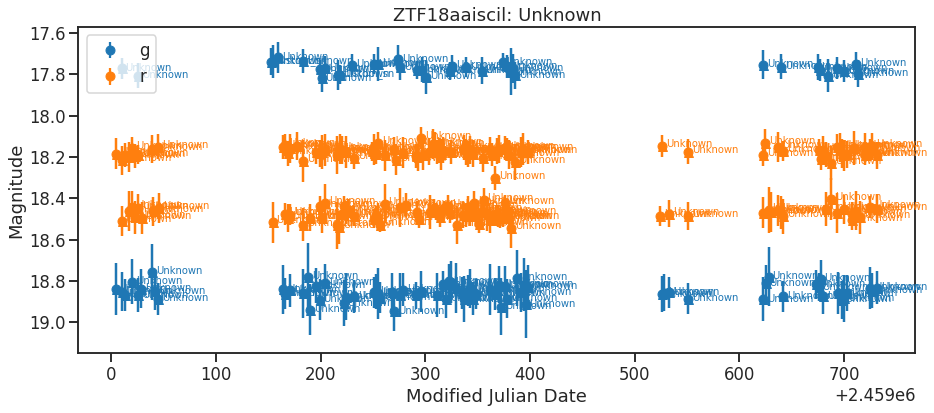

(771, 2) (771, 2) (771, 2)


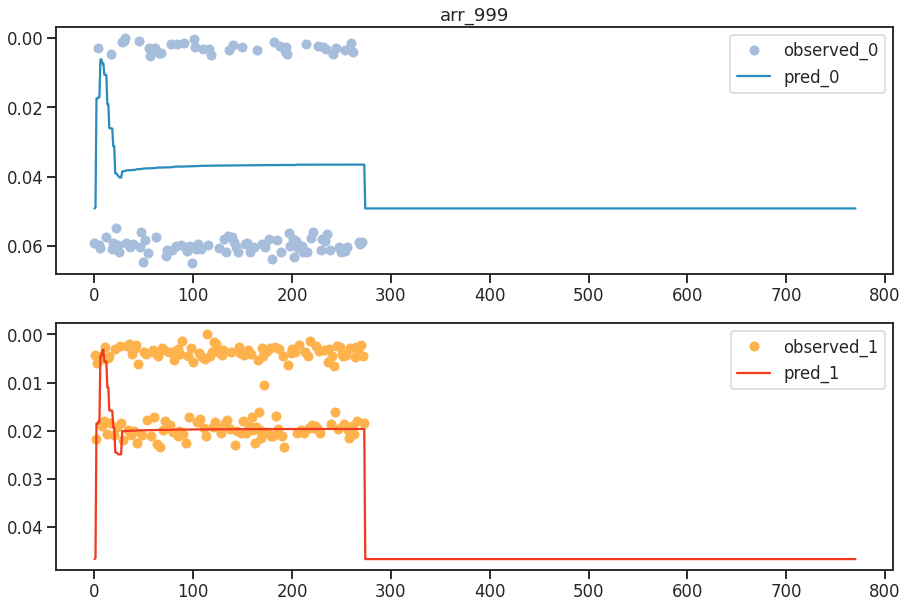

In [68]:
for counter, key in enumerate(decoded_lcs.keys()):
    if counter in max_points_lc_counters:
        currObjId = test_objIds[counter]
        currObjId_index = np.where(total_objIds == currObjId)
        currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
        currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
        plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
        plot_decoded_lc(decoded_lcs, key)

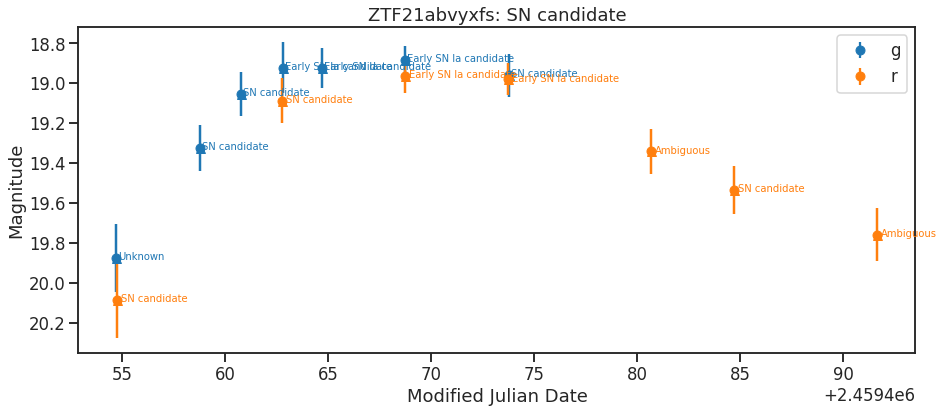

(771, 2) (771, 2) (771, 2)


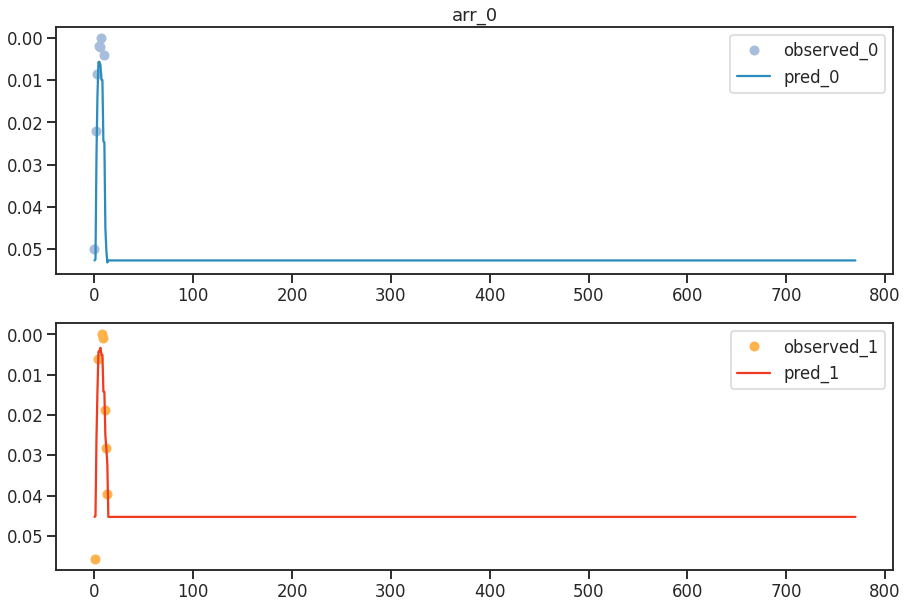

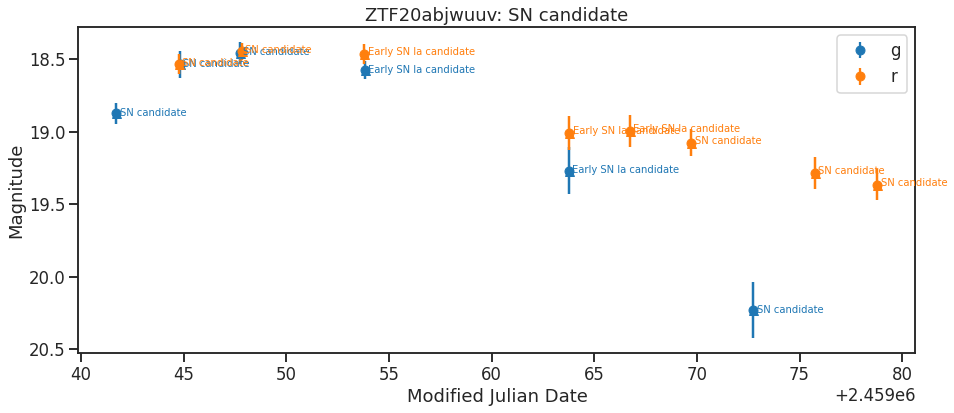

(771, 2) (771, 2) (771, 2)


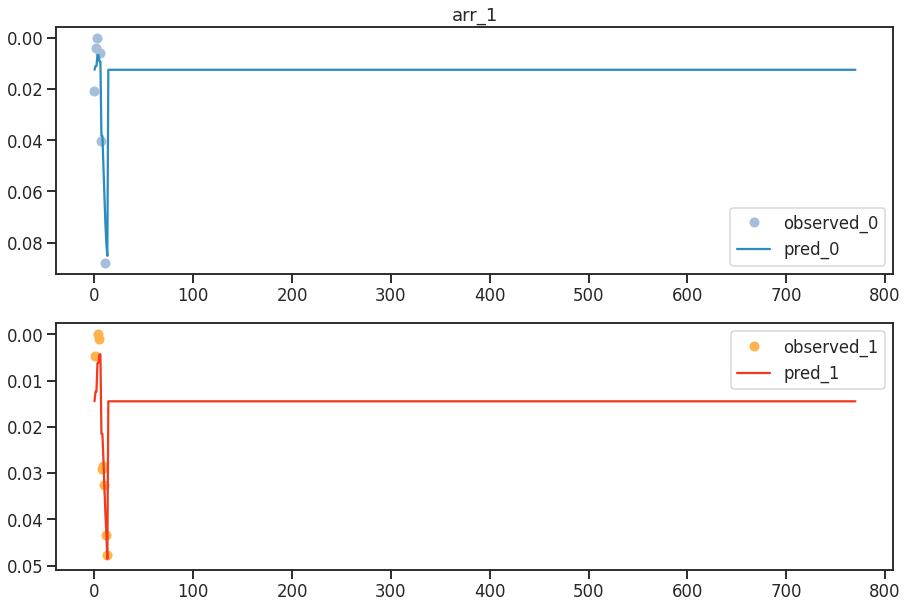

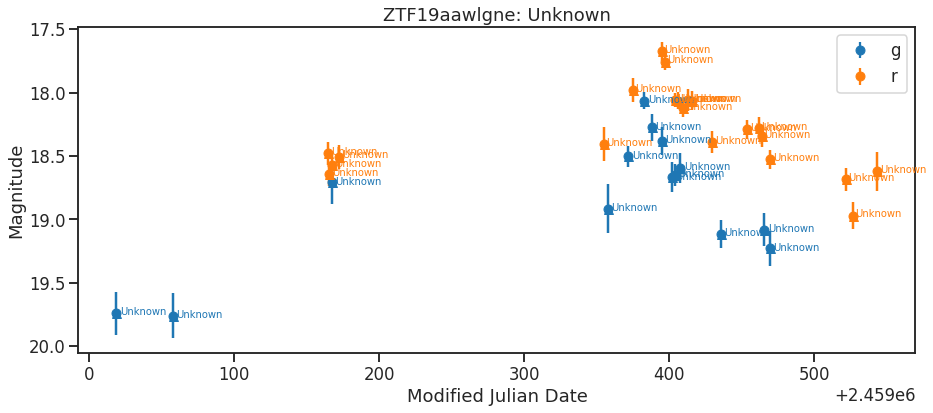

(771, 2) (771, 2) (771, 2)


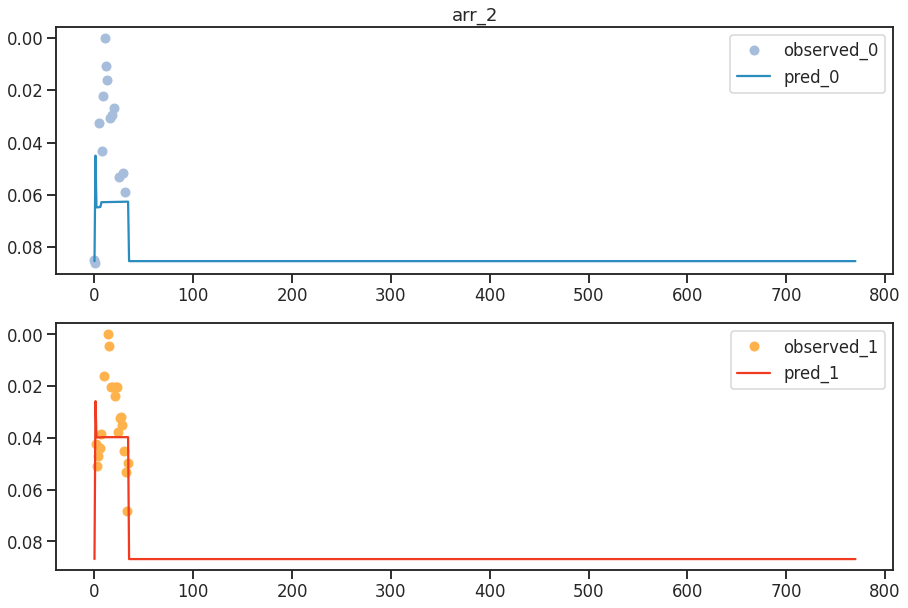

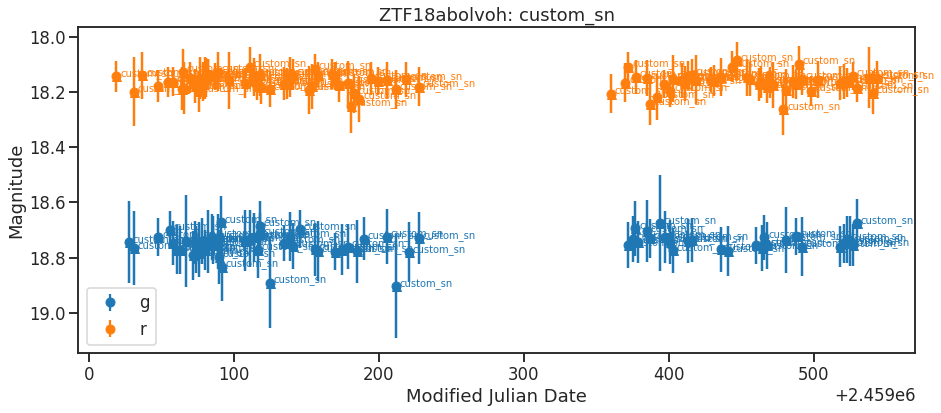

(771, 2) (771, 2) (771, 2)


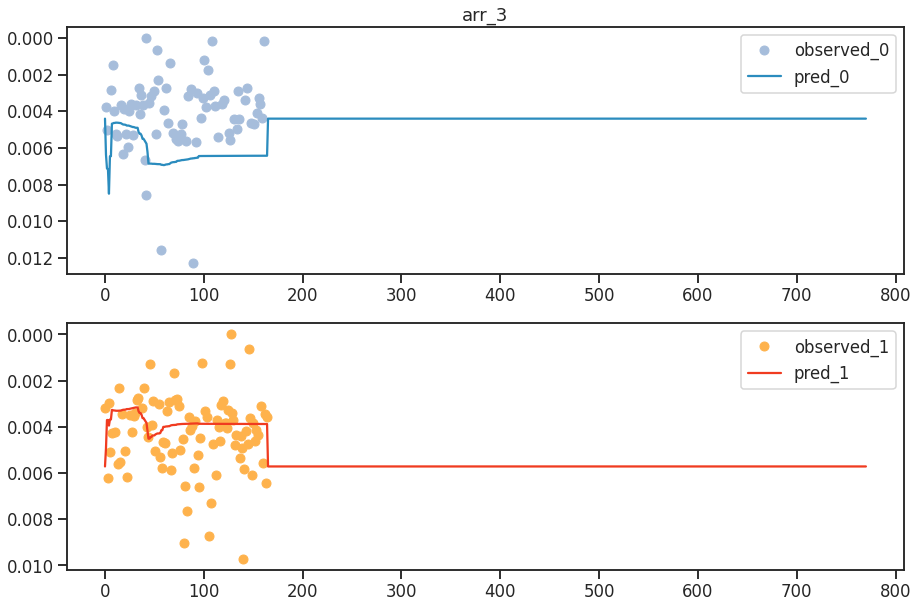

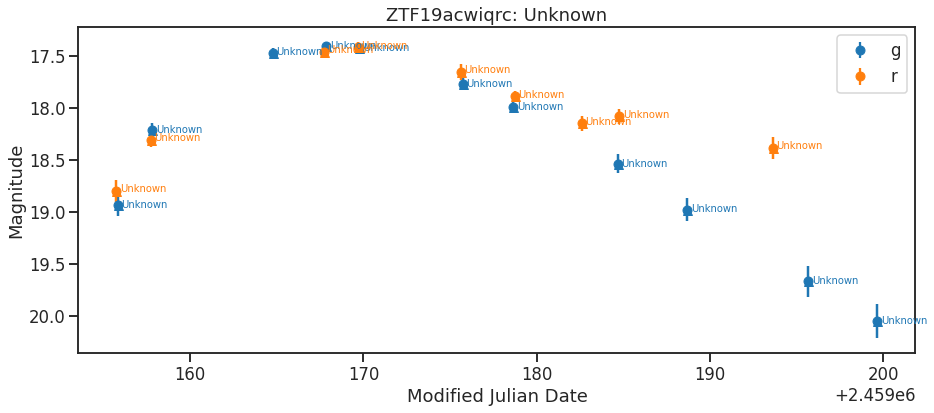

(771, 2) (771, 2) (771, 2)


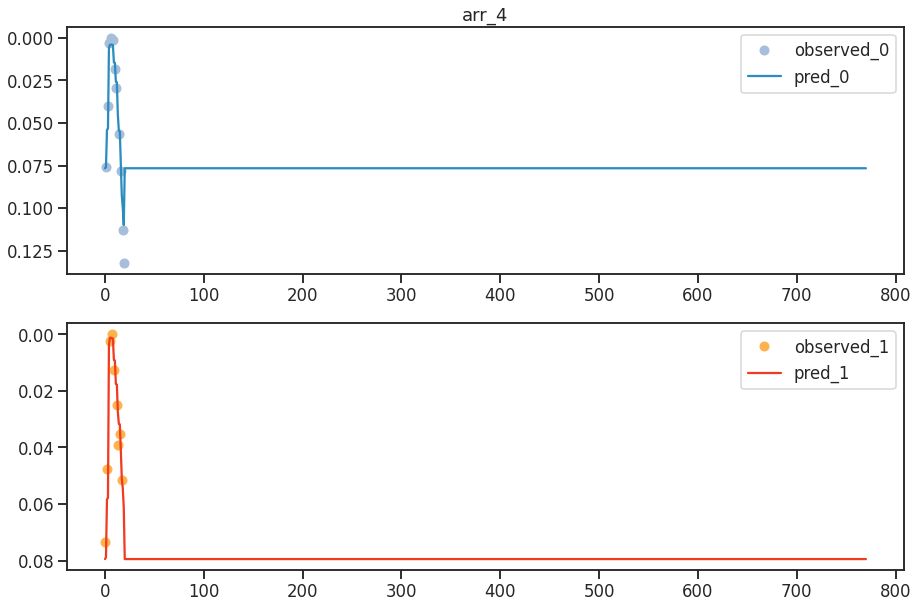

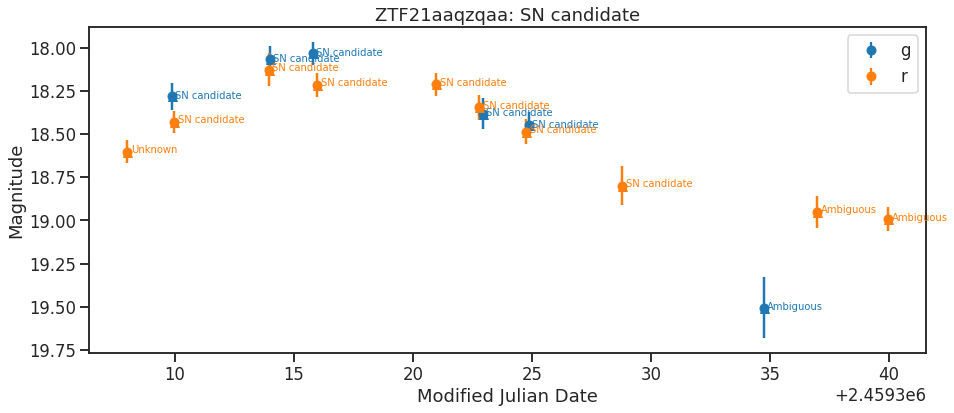

(771, 2) (771, 2) (771, 2)


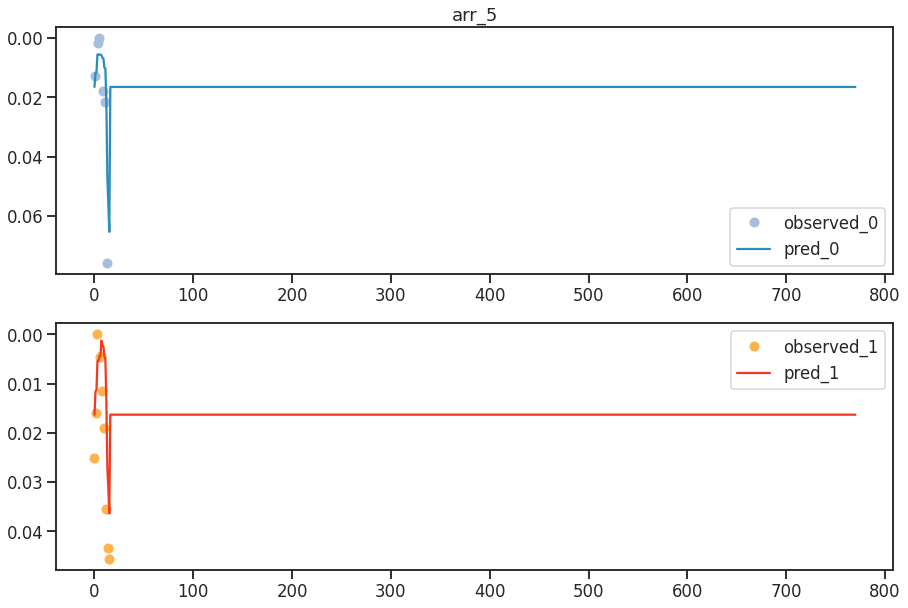

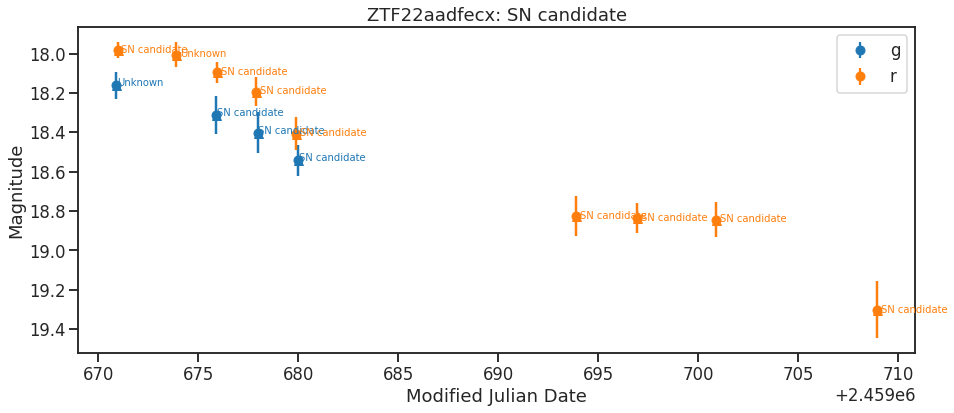

(771, 2) (771, 2) (771, 2)


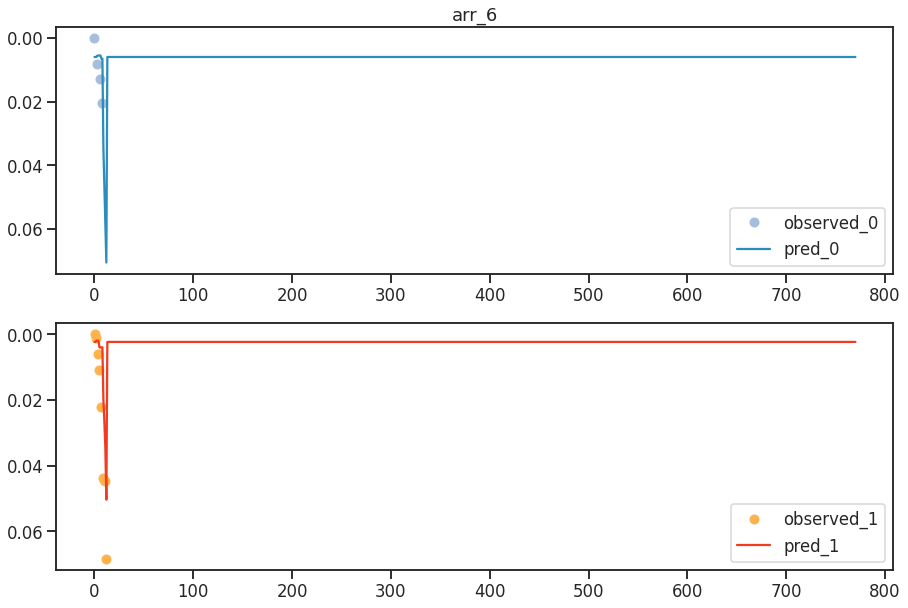

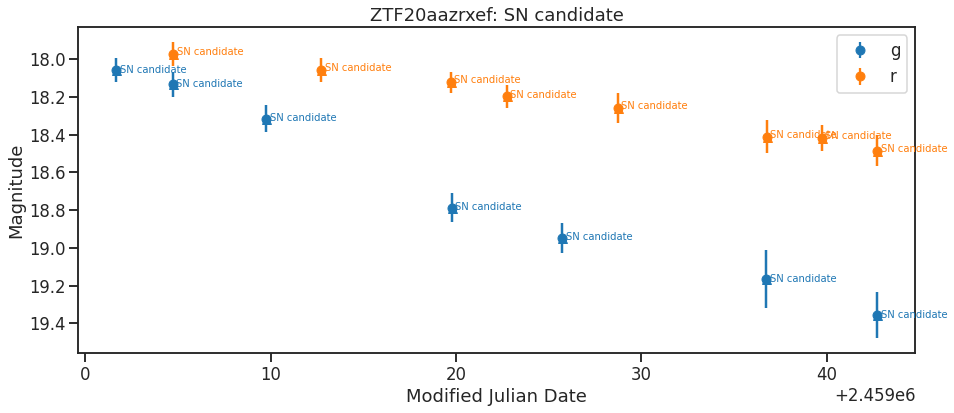

(771, 2) (771, 2) (771, 2)


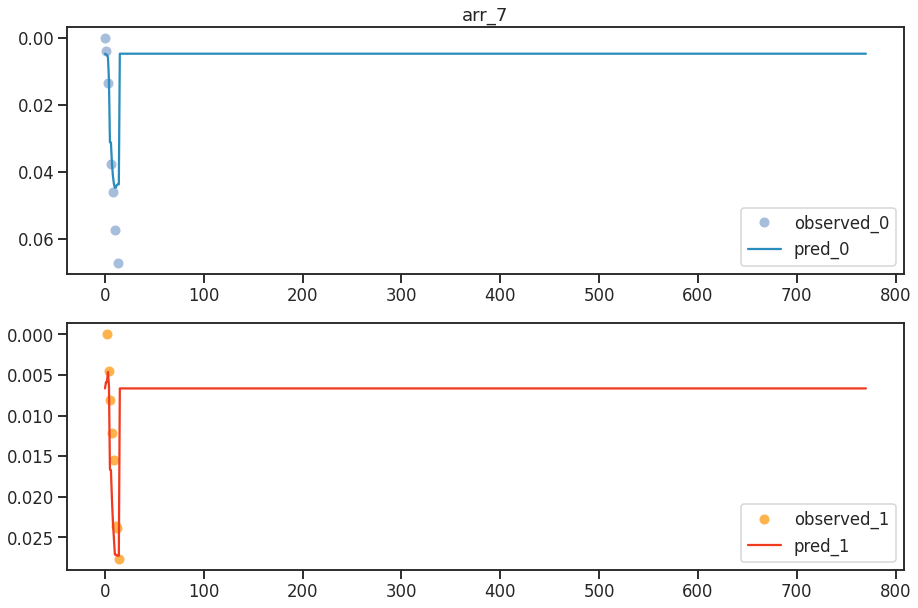

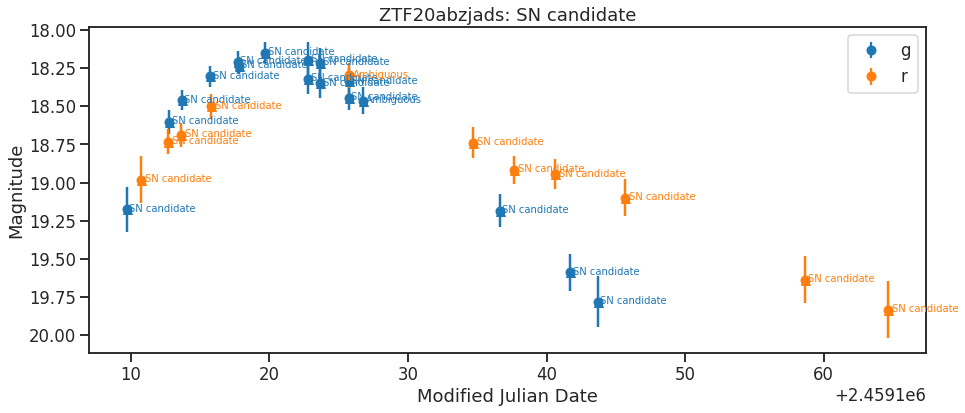

(771, 2) (771, 2) (771, 2)


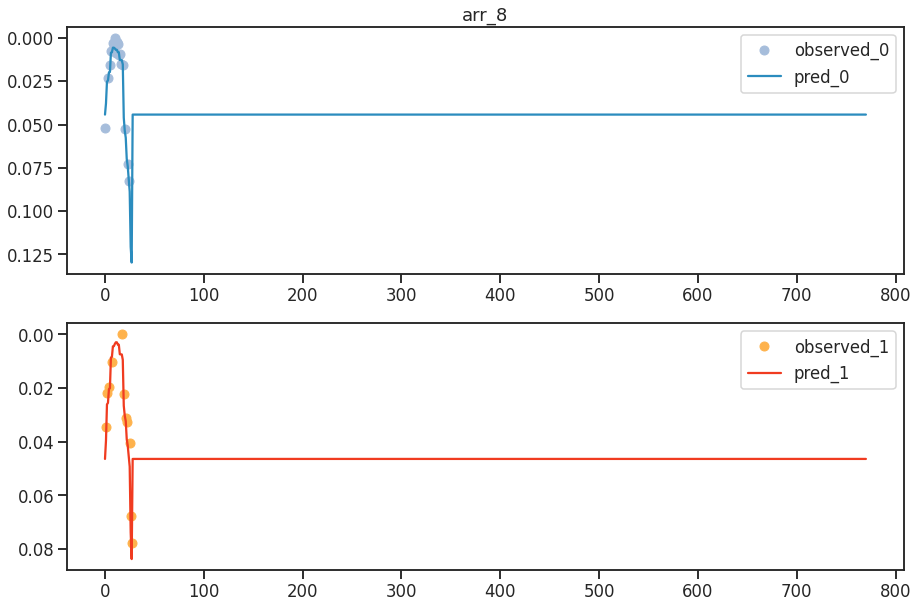

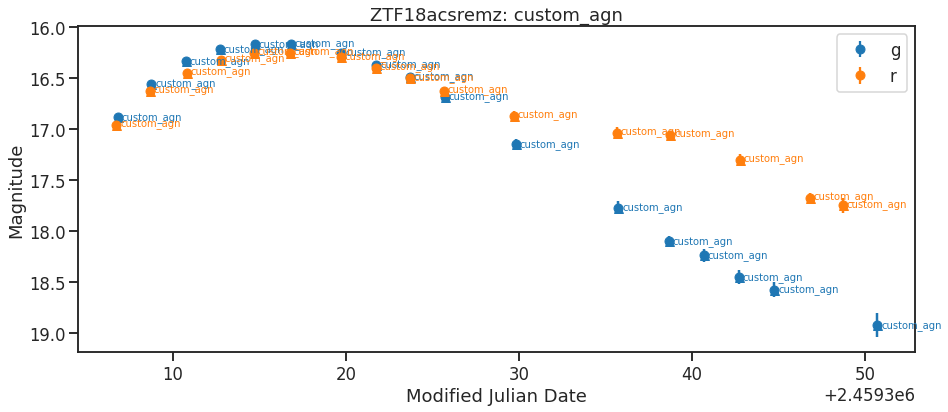

(771, 2) (771, 2) (771, 2)


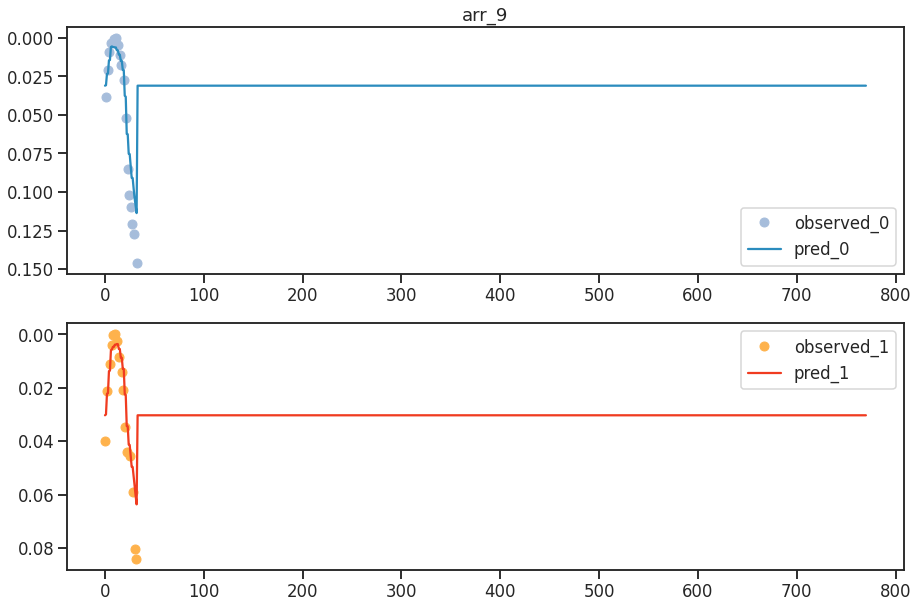

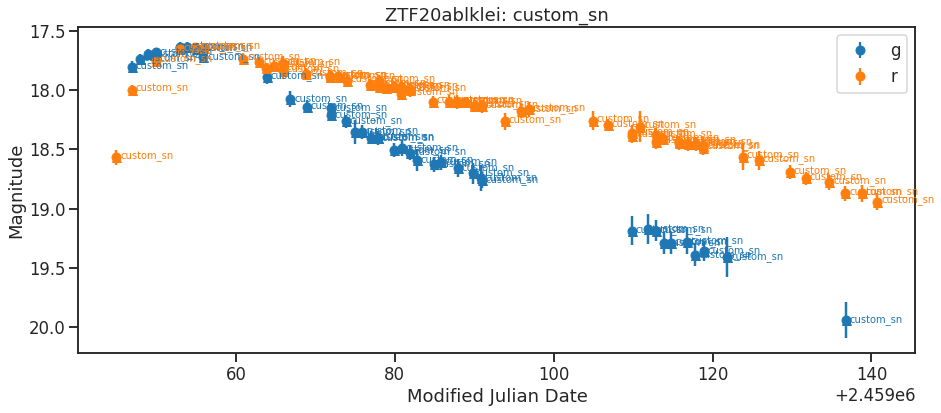

(771, 2) (771, 2) (771, 2)


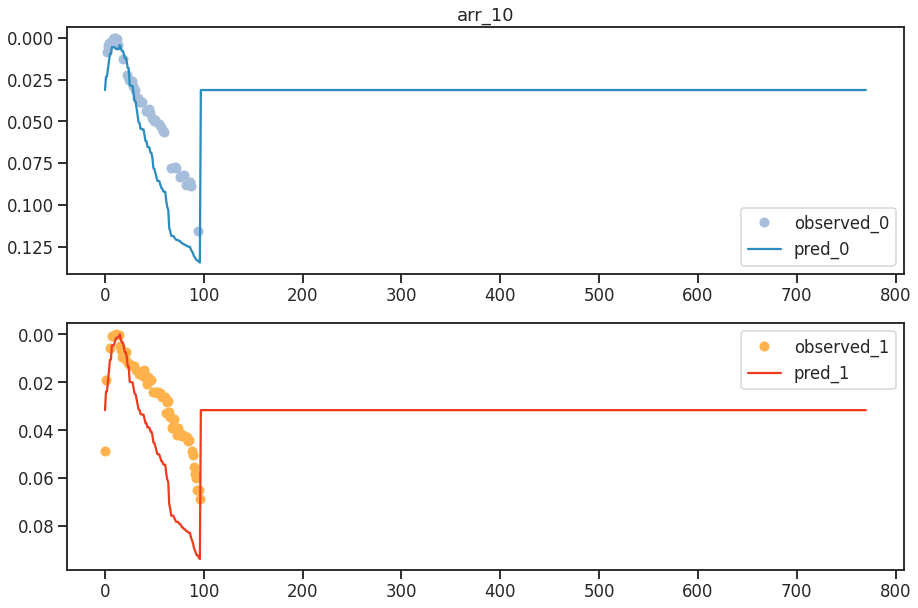

In [69]:
for counter, key in enumerate(decoded_lcs.keys()):
    currObjId = test_objIds[counter]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    plot_decoded_lc(decoded_lcs, key)
    if counter == 10:
        break

## Weird case

duration of this light curve (`ZTF22aadesap`) is greater than 1 year (alerts data range used).

In [47]:
plot_lc(df_alerts, 'ZTF22aadesap')

ValueError: No alerts exist for objectId = ZTF22aadesap!

In [48]:
ZTF22aadesap_alerts = df_alerts[df_alerts['objectId'] == 'ZTF22aadesap']
ZTF22aadesap_alerts['jd'].max() - ZTF22aadesap_alerts['jd'].min()

nan